In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import OrderedDict

In [2]:
# Read the CSV file
df = pd.read_csv('final_cleaned_stock_data.csv')

print(df.tail())

              date ticker  PX_HIGH  PX_LOW  PX_OPEN  PX_LAST  PX_VOLUME  \
127369  2020-12-24    WFC   30.350  29.665    30.35    29.84  2961029.0   
127370  2020-12-28    WFC   30.475  29.910    30.05    29.93  4327450.0   
127371  2020-12-29    WFC   30.165  29.750    30.10    29.78  4343416.0   
127372  2020-12-30    WFC   30.040  29.655    29.80    29.75  4007378.0   
127373  2020-12-31    WFC   30.231  29.680    29.75    30.18  5096866.0   

        PE_RATIO  PX_TO_BOOK_RATIO  PX_TO_SALES_RATIO  \
127369   46.6354            0.7704             1.4291   
127370   46.7761            0.7727             1.4334   
127371   46.5416            0.7688             1.4262   
127372   46.4948            0.7680             1.4248   
127373   58.7160            0.7683             1.5197   

        DAY_TO_DAY_TOT_RETURN_GROSS_DVDS  CUR_MKT_CAP  IVOL_DELTA  \
127369                           -1.6804  123373.1688     41.5216   
127370                            0.3016  123745.2729     43.7803   

## Data Splitting with Expanding Cross-Validation

Keeping the correct time order is very important when working with time-series data.  
Training, validation, and test sets must follow the timeline to avoid using future data to predict the past.

---

### 1. Train / Test Split

Data is split by calendar years:

- **Training Set**  
  Uses five years before the test year.

- **Test Set**  
  One year to be tested. 

Example:

```
Train : 2012-01-01 to 2016-12-31  
Test  : 2017-01-01 to 2017-12-31
```

---

### 2. Expanding Cross-Validation Inside Training Set

To better tune the model, training data is further split using expanding windows:

- The first fold starts 2.5 years after the training begins.
- Each validation period lasts 6 months.
- Each fold uses all past data up to the validation start.

Example folds:

```
CV Fold 1:
  Train: 2012-01-01 to 2014-06-30  
  Val  : 2014-07-01 to 2014-12-31

CV Fold 2:
  Train: 2012-01-01 to 2015-01-01  
  Val  : 2015-01-02 to 2015-06-30

CV Fold 3:
  Train: 2012-01-01 to 2015-07-01  
  Val  : 2015-07-02 to 2015-12-31

CV Fold 4:
  Train: 2012-01-01 to 2016-01-01  
  Val  : 2016-01-02 to 2016-06-30

CV Fold 5:
  Train: 2012-01-01 to 2016-07-01  
  Val  : 2016-07-02 to 2016-12-31
```

In [3]:
def create_expanding_cv_splits(df, test_years, train_years=5, min_cv_folds=5):
    """
    Expanding CV splits:
    - First CV Fold: Train = first 2.5y, Val = next 0.5y
    - Val window fixed to 6 months, expand train each step

    Parameters:
    - df: DataFrame with 'date' column in datetime format
    - test_years: list of int
    - train_years: int, how many years before test year
    - min_cv_folds: minimum number of cv folds to keep this test split

    Returns:
    - splits: list of dicts with train/test/cv folds
    """
    splits = []

    for test_year in test_years:
        test_start = pd.Timestamp(f"{test_year}-01-01")
        test_end = pd.Timestamp(f"{test_year}-12-31")
        train_start = test_start - pd.DateOffset(years=train_years)
        train_end = test_start - pd.Timedelta(days=1)

        # Get sorted unique dates in training range
        train_dates = df[(df['date'] >= train_start) & (df['date'] <= train_end)]['date'].drop_duplicates().sort_values().reset_index(drop=True)
        if len(train_dates) == 0:
            continue

        # First val_start = train_start + 2.5 years
        first_val_start = train_start + pd.DateOffset(years=2, months=6)
        val_start = pd.Timestamp(first_val_start)
        val_folds = []

        while True:
            # Validation = 6 months
            val_end = (val_start + pd.DateOffset(months=6)) - pd.DateOffset(months=1)
            val_end = pd.Timestamp(val_end.year, val_end.month, 1) + pd.offsets.MonthEnd(0)

            if val_end > train_end:
                break

            train_fold_end = val_start - pd.Timedelta(days=1)

            val_folds.append({
                'train_start': train_start,
                'train_end': train_fold_end,
                'val_start': val_start,
                'val_end': val_end
            })

            # Slide val window forward by 6 months
            val_start += pd.DateOffset(months=6)

        if len(val_folds) < min_cv_folds:
            continue

        splits.append({
            'test_year': test_year,
            'train_period': (train_start, train_end),
            'test_period': (test_start, test_end),
            'cv_folds': val_folds
        })

    return splits


In [4]:
df['date'] = pd.to_datetime(df['date'])

# Call the expanding CV splitting function
splits = create_expanding_cv_splits(df, test_years=[2017, 2018, 2019, 2020])

# Print the structure of each split round
for s in splits:
    print(f"\nTest Year: {s['test_year']}")
    print(f"  Train : {s['train_period'][0].date()} ~ {s['train_period'][1].date()}")
    print(f"  Test  : {s['test_period'][0].date()} ~ {s['test_period'][1].date()}")
    for i, fold in enumerate(s['cv_folds'], 1):
        print(f"    CV Fold {i}:")
        print(f"      Train : {fold['train_start'].date()} ~ {fold['train_end'].date()}")
        print(f"      Val   : {fold['val_start'].date()} ~ {fold['val_end'].date()}")



Test Year: 2017
  Train : 2012-01-01 ~ 2016-12-31
  Test  : 2017-01-01 ~ 2017-12-31
    CV Fold 1:
      Train : 2012-01-01 ~ 2014-06-30
      Val   : 2014-07-01 ~ 2014-12-31
    CV Fold 2:
      Train : 2012-01-01 ~ 2014-12-31
      Val   : 2015-01-01 ~ 2015-06-30
    CV Fold 3:
      Train : 2012-01-01 ~ 2015-06-30
      Val   : 2015-07-01 ~ 2015-12-31
    CV Fold 4:
      Train : 2012-01-01 ~ 2015-12-31
      Val   : 2016-01-01 ~ 2016-06-30
    CV Fold 5:
      Train : 2012-01-01 ~ 2016-06-30
      Val   : 2016-07-01 ~ 2016-12-31

Test Year: 2018
  Train : 2013-01-01 ~ 2017-12-31
  Test  : 2018-01-01 ~ 2018-12-31
    CV Fold 1:
      Train : 2013-01-01 ~ 2015-06-30
      Val   : 2015-07-01 ~ 2015-12-31
    CV Fold 2:
      Train : 2013-01-01 ~ 2015-12-31
      Val   : 2016-01-01 ~ 2016-06-30
    CV Fold 3:
      Train : 2013-01-01 ~ 2016-06-30
      Val   : 2016-07-01 ~ 2016-12-31
    CV Fold 4:
      Train : 2013-01-01 ~ 2016-12-31
      Val   : 2017-01-01 ~ 2017-06-30
    CV Fold

## Construct Excess Forward Return

This step computes *excess forward returns* for each stock over multiple holding horizons  
by subtracting risk-free returns from raw forward returns.

---

### Forward Return Formula

For a given holding horizon $h \in \{1, 5, 20, 40\}$, the raw forward return is computed as:

$$
\text{ForwardReturn}_{i,t}^{(h)} = \frac{P_{i,t+h}}{P_{i,t}} - 1
$$

Where:  
- $P_{i,t}$: Closing price of stock $i$ at time $t$  
- $P_{i,t+h}$: Closing price after $h$ business days

---

### Risk-Free Rate Adjustment

To compute excess return, subtract the cumulative risk-free return over $h$ days,  
assuming a constant daily rate based on the observed risk-free rate at time $t$:

$$
\text{ExcessReturn}_{i,t}^{(h)} = \text{ForwardReturn}_{i,t}^{(h)} - h \cdot \text{RF}_{\text{daily}, t}
$$

Where:  
- $\text{RF}_{\text{daily}, t} = \frac{\text{AnnualRate}_t}{252}$  
- The risk-free rate is sourced from 3-month Treasury yield (`USGG3M Index`),  
  provided in the Excel file `rf.xlsx`

---

### Data Used

- `equity_long_format.csv`:  
  Contains stock prices (`PX_LAST`) by `ticker` and `date`

- `rf.xlsx`:  
  Contains daily risk-free rates in annualized percentage format  
  Converted to daily return via: $\text{rf\_rate} / 100 / 252$

---

In [5]:
# Step 1: Load equity data
forward_return_df = pd.read_csv("filtered_pxlast_2010_2022.csv")
forward_return_df['date'] = pd.to_datetime(forward_return_df['date'])
forward_return_df = forward_return_df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Step 2: Load and process risk-free rate
rf_df = pd.read_excel("rf.xlsx")
rf_df.columns = ['date', 'rf_rate']
rf_df = rf_df[1:]
rf_df['date'] = pd.to_datetime(rf_df['date'])
rf_df['rf_rate'] = rf_df['rf_rate'].astype(float)
rf_df['daily_rf_return'] = rf_df['rf_rate'] / 100 / 252
rf_df = rf_df.sort_values('date').reset_index(drop=True)

# Step 3: Merge rf into price dataframe
forward_return_df = pd.merge(forward_return_df, rf_df[['date', 'daily_rf_return']], on='date', how='left')

# Step 4: Calculate forward returns
for h in [1, 5, 20, 40]:
    raw_col = f'fwd_return_raw_{h}d'
    main_col = f'fwd_return_{h}d'

    # Calculate raw forward return
    forward_return_df[raw_col] = forward_return_df.groupby('ticker')['PX_LAST'].transform(
        lambda x: x.shift(-h) / x - 1
    )

    # Calculate excess forward return
    forward_return_df[main_col] = forward_return_df[raw_col] - h * forward_return_df['daily_rf_return']

# Step 5: Merge back to main df
df['date'] = pd.to_datetime(df['date'])
cols_to_merge = ['ticker', 'date'] + [f'fwd_return_{h}d' for h in [1, 5, 20, 40]]
df = pd.merge(df, forward_return_df[cols_to_merge], on=['ticker', 'date'], how='left')

In [6]:
# Merge daily_rf_return into existing df
df = pd.merge(df, rf_df[['date', 'daily_rf_return']], on='date', how='left')

In [7]:
print(df.isna().sum())

date                                0
ticker                              0
PX_HIGH                             0
PX_LOW                              0
PX_OPEN                             0
PX_LAST                             0
PX_VOLUME                           0
PE_RATIO                            0
PX_TO_BOOK_RATIO                    0
PX_TO_SALES_RATIO                   0
DAY_TO_DAY_TOT_RETURN_GROSS_DVDS    0
CUR_MKT_CAP                         0
IVOL_DELTA                          0
CALL_IMP_VOL_30D                    0
IVOL_IMPLIED_FORWARD                0
fwd_return_1d                       0
fwd_return_5d                       0
fwd_return_20d                      0
fwd_return_40d                      0
daily_rf_return                     0
dtype: int64


# Feature Engineering

## 1. Carry Signal

This section evaluates the predictive power of the EWMA-smoothed carry signal for future stock returns.  
It performs cross-sectional OLS regressions and assesses statistical significance using T-statistics.

---

### 1.1 Compute Daily Carry Signal

Carry is defined as the relative difference between the current spot price and the implied forward price:

$$
\text{Carry}_t = \frac{\text{PX\_LAST}_t - \text{IVOL\_IMPLIED\_FORWARD}_t}{\text{IVOL\_IMPLIED\_FORWARD}_t}
$$

This metric captures the slope or steepness between current and future expected price levels.

---

### 1.2 Smooth Carry Signal Using EWMA

To reduce noise, the raw daily carry signal is smoothed using an Exponentially Weighted Moving Average (EWMA).  
Four different EWMA smoothing windows are applied:

- 5 trading days  
- 20 trading days  
- 120 trading days  
- 250 trading days

---

### 1.3 In-Sample Period Selection

The in-sample evaluation uses data from:

$$
\text{Period: } \text{2012-01-01 to 2016-12-31}
$$

This range serves as the training set for all signal regressions.

---

### 1.4 Run OLS Regressions

For each EWMA carry signal and forward return horizon, an OLS regression is run cross-sectionally:

$$
\text{Return}_{t+h} = \alpha + \beta \cdot \text{CarrySignal}_t + \varepsilon_t
$$

The regressions produce the following metrics:

- Coefficient $\beta$  
- T-statistic of $\beta$: tests $H_0: \beta = 0$  
- R-squared (explained variance)  
- p-value (significance level)  
- Number of observations used

---

### 1.5 Interpretation of T-Statistic

The T-statistic of each regression is used to evaluate signal strength:

- $|\text{T}| > 2$: statistically significant predictive power at 5% level  
- $\text{T} > 0$: signal positively predicts returns  
- $\text{T} < 0$: signal negatively predicts returns

This analysis allows identification of the optimal EWMA span for constructing the carry signal.

## Best Window Selection Logic

**Objective**  
Among all candidate windows for each signal (e.g., 5, 20, 120, 250 days), select the window with the strongest and most robust performance based on $t$-statistics from regressions across multiple forward-return horizons (e.g., 1d, 5d, 20d, 40d). Evaluation considers both the worst case (lowest significance) and the average level.

---

**Metrics**

- For each signal–window pair, compute absolute $t$-statistics across all forward horizons: $|t|$.
- Aggregate two window-level metrics:  
  - $\text{min\_abs\_t} = \min(|t|)$: the smallest $|t|$ across horizons (the weakest significance)  
  - $\text{mean\_abs\_t} = \text{mean}(|t|)$: the average $|t|$ across horizons (overall strength)

Let $t_{i,j}$ be the $t$-statistic for window $i$ at horizon $j$ (with $N$ horizons). Then:

- Minimum absolute $t$-value:  
  $$
  \min |t_i| = \min_{j}\,|t_{i,j}|
  $$
- Average absolute $t$-value:  
  $$
  \mathrm{mean}|t_i| = \frac{1}{N}\sum_{j=1}^{N}\!|t_{i,j}|
  $$

---

**Ranking & Scoring Rules**

1. Rank $\text{min\_abs\_t}$ in **ascending** order using dense rank → $\text{min\_rank}$
2. Rank $\text{mean\_abs\_t}$ in **ascending** order using dense rank → $\text{mean\_rank}$
3. Compute composite score:  
   $$
   \text{rank\_score} = \text{min\_rank} + \text{mean\_rank}
   $$
4. Select window with the **largest** $\text{rank\_score}$ (higher total → better in both metrics)
5. Tie-break by selecting the window with **larger** $\text{mean\_abs\_t}$

---

**Example**

Assume three candidate windows for a given signal:

| Window | $\text{min\_abs\_t}$ | $\text{mean\_abs\_t}$ |
|--------|---------------------:|-----------------------:|
| 5      | 3                   | 4                     |
| 20     | 6                   | 3                     |
| 60     | 2                   | 1                     |

- Ascending dense ranks:  
  - $\text{min\_rank}$: 5→2, 20→3, 60→1  
  - $\text{mean\_rank}$: 5→3, 20→2, 60→1  

- Composite scores:  
  - 5-day: $2 + 3 = 5$  
  - 20-day: $3 + 2 = 5$  
  - 60-day: $1 + 1 = 2$

- Final selection: both 5-day and 20-day score 5 → tie-break on $\text{mean\_abs\_t}$ → 5-day wins

## Chart Analysis

This chart shows the T-statistics from pooled OLS regressions of various EWMA-smoothed carry signals  
on forward returns of different horizons, using data from the 2012–2016 training set.

---

### Key Observations

- The T-statistics are **consistently weak**, with many values close to 0 and none exceeding ±2.
- The **strongest absolute t-statistic is only 0.59**, indicating no statistical significance across any EWMA span or return horizon.
- The **best-performing span** is EWMA = 5, but even that shows very weak signal strength.
- Longer EWMA spans (120, 250) show near-zero t-values, indicating no reliable relationship between carry and future returns.

---

### Summary Statistics

- **Best EWMA Span**: 5  
- **Minimum $|t|$**: 0.24  
- **Mean $|t|$**: 0.35

---

### Conclusion

- The EWMA carry signal exhibits **no meaningful predictive power** during the 2012–2016 period.
- T-statistics are close to zero across all smoothing spans and return horizons, indicating that the carry signal is likely dominated by noise.
- **This signal is not retained** for downstream strategy development.

In [8]:
# Compute daily carry signal as the relative difference between spot price and implied forward price
df['daily_carry_signal'] = (df['PX_LAST'] - df['IVOL_IMPLIED_FORWARD']) / df['IVOL_IMPLIED_FORWARD']

# Ensure the DataFrame is sorted by ticker and date for proper time-series calculations
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date'])

# Define EWMA smoothing windows (in trading days)
ewma_windows = [5, 20, 120, 250]

# Calculate exponentially weighted moving average (EWMA) of the carry signal for each ticker
for span in ewma_windows:
    df[f'carry_ewma_{span}'] = df.groupby('ticker')['daily_carry_signal'].transform(
        lambda x: x.ewm(span=span, adjust=False).mean()
    )

Best EWMA Carry Signal Span: 5
   - Min |t|: 0.24
   - Mean |t|: 0.35


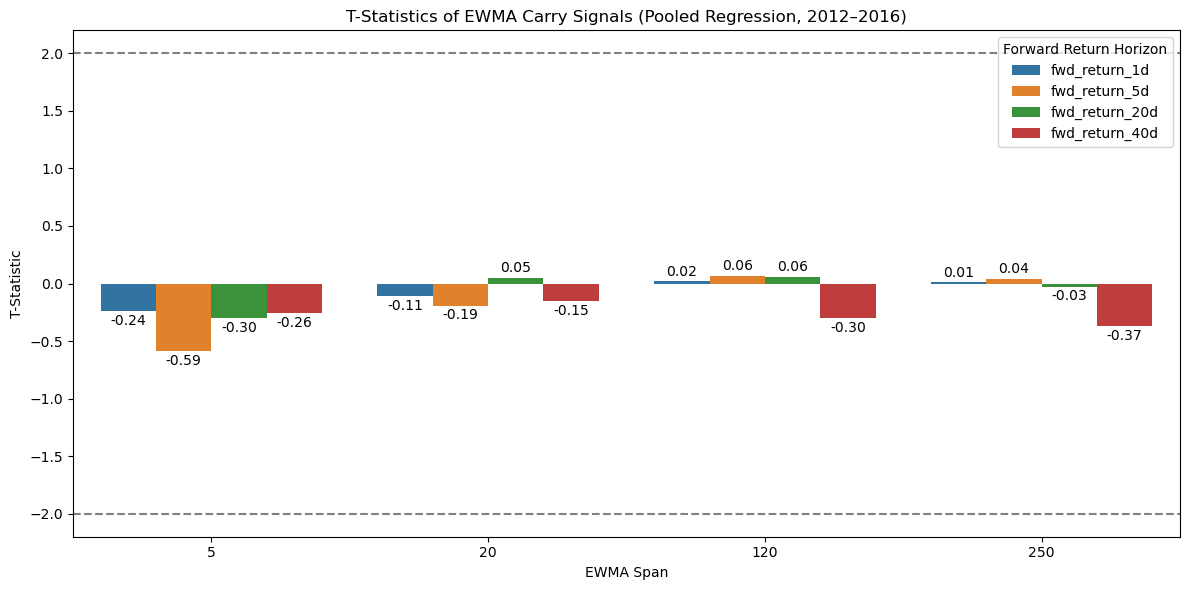

In [9]:
# 1. Define Training Period
train_df = df[(df['date'] >= "2012-01-01") & (df['date'] <= "2016-12-31")]

# 2. Define Signals and Targets
carry_signals = [f'carry_ewma_{span}' for span in [5, 20, 120, 250]]
forward_returns = [f'fwd_return_{h}d' for h in [1, 5, 20, 40]]

# 3. Run Pooled Regression
results = []
for signal in carry_signals:
    for target in forward_returns:
        temp_df = train_df[[signal, target]].dropna()
        if len(temp_df) < 20:
            continue
        X = sm.add_constant(temp_df[signal])
        y = temp_df[target]
        try:
            model = sm.OLS(y, X).fit()
            t_val = model.tvalues[signal]
            coef = model.params[signal]
        except:
            continue
        results.append({
            'signal': signal,
            'target': target,
            'n_obs': len(temp_df),
            't_value': t_val,
            'coef': coef
        })

# 4. Organize Results
result_df = pd.DataFrame(results)
result_df['signal_short'] = result_df['signal'].str.replace('carry_ewma_', '')

# 5. Compute Summary Metrics
result_df['abs_t'] = result_df['t_value'].abs()
agg_df = result_df.groupby('signal_short').agg(
    min_abs_t=('abs_t', 'min'),
    mean_abs_t=('abs_t', 'mean')
).reset_index()

# Rank by smallest-to-largest |t|, then sum ranks
agg_df['min_rank'] = agg_df['min_abs_t'].rank(method='dense', ascending=True)
agg_df['mean_rank'] = agg_df['mean_abs_t'].rank(method='dense', ascending=True)
agg_df['rank_score'] = agg_df['min_rank'] + agg_df['mean_rank']

# Tie-breaker: if rank_score ties, pick highest mean_abs_t
agg_df = agg_df.sort_values(
    ['rank_score', 'mean_abs_t'],
    ascending=[False, False]
).reset_index(drop=True)

# 6. Print Best Signal
best = agg_df.iloc[0]
print(f"Best EWMA Carry Signal Span: {best['signal_short']}")
print(f"   - Min |t|: {best['min_abs_t']:.2f}")
print(f"   - Mean |t|: {best['mean_abs_t']:.2f}")

# 7. Plot T-Statistics
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=result_df,
    x='signal_short',
    y='t_value',
    hue='target'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=2)
plt.axhline(2, color='gray', linestyle='--')
plt.axhline(-2, color='gray', linestyle='--')
plt.title('T-Statistics of EWMA Carry Signals (Pooled Regression, 2012–2016)')
plt.xlabel('EWMA Span')
plt.ylabel('T-Statistic')
plt.legend(title='Forward Return Horizon')
plt.tight_layout()
plt.show()

In [10]:
# Delete all carry signal columns
columns_to_drop = ['daily_carry_signal', 'carry_ewma_5', 'carry_ewma_20', 'carry_ewma_120', 'carry_ewma_250']
df = df.drop(columns=columns_to_drop)
df.head()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,DAY_TO_DAY_TOT_RETURN_GROSS_DVDS,CUR_MKT_CAP,IVOL_DELTA,CALL_IMP_VOL_30D,IVOL_IMPLIED_FORWARD,fwd_return_1d,fwd_return_5d,fwd_return_20d,fwd_return_40d,daily_rf_return
0,2010-01-04,ACN,42.20,41.50,41.50,42.07,1122800.0,16.3173,10.6855,1.1719,1.3735,30755.6768,21.7763,21.359,41.9751,0.006178,0.010923,-0.010740,-0.034078,0.000002
1,2010-01-05,ACN,42.45,41.99,42.09,42.33,755600.0,16.4182,10.7516,1.1791,0.6180,30945.7523,21.7763,20.715,42.3300,0.010628,-0.001666,-0.017294,-0.033642,0.000002
2,2010-01-06,ACN,42.90,41.81,42.09,42.78,1361300.0,16.5927,10.8659,1.1916,1.0631,31274.7291,21.7763,20.260,42.7800,-0.000937,-0.000945,-0.050763,-0.037478,0.000002
3,2010-01-07,ACN,42.89,42.24,42.43,42.74,1402100.0,16.5772,10.8557,1.1905,-0.0935,31245.4867,25.3271,21.148,42.8503,-0.003979,0.008882,-0.051509,-0.030018,0.000002
4,2010-01-08,ACN,43.06,42.20,42.35,42.57,1363800.0,16.5112,10.8125,1.1858,-0.3978,31121.2066,23.5517,20.737,42.5700,-0.000941,0.005630,-0.056409,-0.012043,0.000002


## 2. Volatility Risk Premium via ATR (average true range) vs Std (standard deviation) Volatility

### Objective

Assess the predictive power of **Volatility Risk Premium (VRP)** signals on future stock returns, defined as:

$$
\text{VRP}_t = \frac{\sigma^{\text{real}}_t - \sigma^{\text{impl}}_t}{\sigma^{\text{impl}}_t}
$$

Where:

- $\sigma^{\text{impl}}_t$: Implied volatility from options (`IVOL_DELTA`)  
- $\sigma^{\text{real}}_t$: Realized volatility estimated via standard deviation or ATR

---

### Motivation for ATR-Based Realized Volatility

Standard deviation calculates volatility using only daily close prices, which ignores intra-day price movements and overnight gaps.
ATR (Average True Range) incorporates daily high, low, and previous close, making it a more realistic measure of actual price fluctuations.

True Range $\tau_t$ is defined as:

$$
\tau_t = \max \left\{
\begin{aligned}
& \text{High}_t - \text{Low}_t \\
& |\text{High}_t - \text{Close}_{t-1}| \\
& |\text{Low}_t - \text{Close}_{t-1}|
\end{aligned}
\right.
$$

ATR-based annualized realized volatility:

$$
\sigma^{\text{ATR}}_t = \frac{\text{EMA}_n(\tau_t)}{\text{Close}_t} \cdot \sqrt{252} \cdot 100
$$

---

### Signal Construction

Construct two types of VRP signals over multiple volatility windows (5, 20, 120, 250 days):

- Using standard deviation:

$$
\text{VRP}^{\text{std}}_t = \frac{\sigma^{\text{std}}_t - \sigma^{\text{impl}}_t}{\sigma^{\text{impl}}_t}
$$

- Using ATR:

$$
\text{VRP}^{\text{ATR}}_t = \frac{\sigma^{\text{ATR}}_t - \sigma^{\text{impl}}_t}{\sigma^{\text{impl}}_t}
$$

---

### Regression Framework

For each signal and return horizon, estimate univariate regression:

$$
r_{t+h} = \alpha + \beta \cdot \text{VRP}_t + \varepsilon_t
$$

Where:

- $r_{t+h}$: forward return over $h$ days (e.g., 1d, 5d, 20d, 40d)  
- $\beta$: sensitivity to VRP, measures whether signal predicts return

---

### Visualization

- Create two vertically stacked bar charts (ATR vs Std)  
- Use t-statistic on Y-axis, volatility window on X-axis  
- Add horizontal lines at $t = \pm 2$ for significance threshold

## Chart Analysis

### Volatility Estimation Method

Standard deviation-based VRP signal outperforms ATR-based version across all forward return horizons.  
T-values are consistently more negative and statistically significant at every volatility window.

---

### Volatility Window

250-day window yields:

- Minimum $|t|$: 8.20  
- Mean $|t|$: 15.33

---

### Signal Direction

All t-values are negative: higher VRP predicts lower future returns.  
Invert sign to align with positive return forecasting:

$$
\text{Signal}_t = -\text{VRP}_t = \frac{\sigma^{\text{impl}}_t - \sigma^{\text{real}}_t}{\sigma^{\text{impl}}_t}
$$

---

### Final Choice

- Signal type: standard deviation-based VRP  
- Volatility window: 250 days  
- Signal direction: negative of raw VRP  

In [11]:
# Calculate previous day's closing price
df['prev_close'] = df.groupby('ticker')['PX_LAST'].shift(1)

# Compute the True Range τ_t
df['true_range'] = df[['PX_HIGH', 'PX_LOW', 'prev_close']].apply(
    lambda x: max(
        x['PX_HIGH'] - x['PX_LOW'],
        abs(x['PX_HIGH'] - x['prev_close']),
        abs(x['PX_LOW'] - x['prev_close'])
    ), axis=1
)

# Compute Annualized ATR-based Realized Volatility (in percentage terms)
for n in [5, 20, 120, 250]:
    zeta = 2 / (n + 1)  # EMA decay factor
    raw_atr = df.groupby('ticker')['true_range'].transform(
        lambda x: x.ewm(alpha=zeta, adjust=False).mean()
    )
    df[f'atr_vol_{n}'] = (raw_atr / df['PX_LAST']) * (252 ** 0.5) * 100  # Annualized %

# Compute Volatility Risk Premium (VRP) signal using IVOL_DELTA and ATR-based realized vol
# Formula: (Realized Vol - Implied Vol) / Implied Vol
for window in [5, 20, 120, 250]:
    df[f'vrp_atr_{window}'] = (df[f'atr_vol_{window}'] - df['IVOL_DELTA']) / df['IVOL_DELTA']

# Compute Std-based Realized Volatility (annualized)
for n in [5, 20, 120, 250]:
    rolling_std = df.groupby('ticker')['PX_LAST'].transform(
        lambda x: x.pct_change().rolling(n).std()
    )
    df[f'std_vol_{n}'] = rolling_std * np.sqrt(252) * 100  # Annualized %

# Compute Std-based VRP Signal: (realized - implied) / implied
for n in [5, 20, 120, 250]:
    df[f'vrp_std_{n}'] = (df[f'std_vol_{n}'] - df['IVOL_DELTA']) / df['IVOL_DELTA']


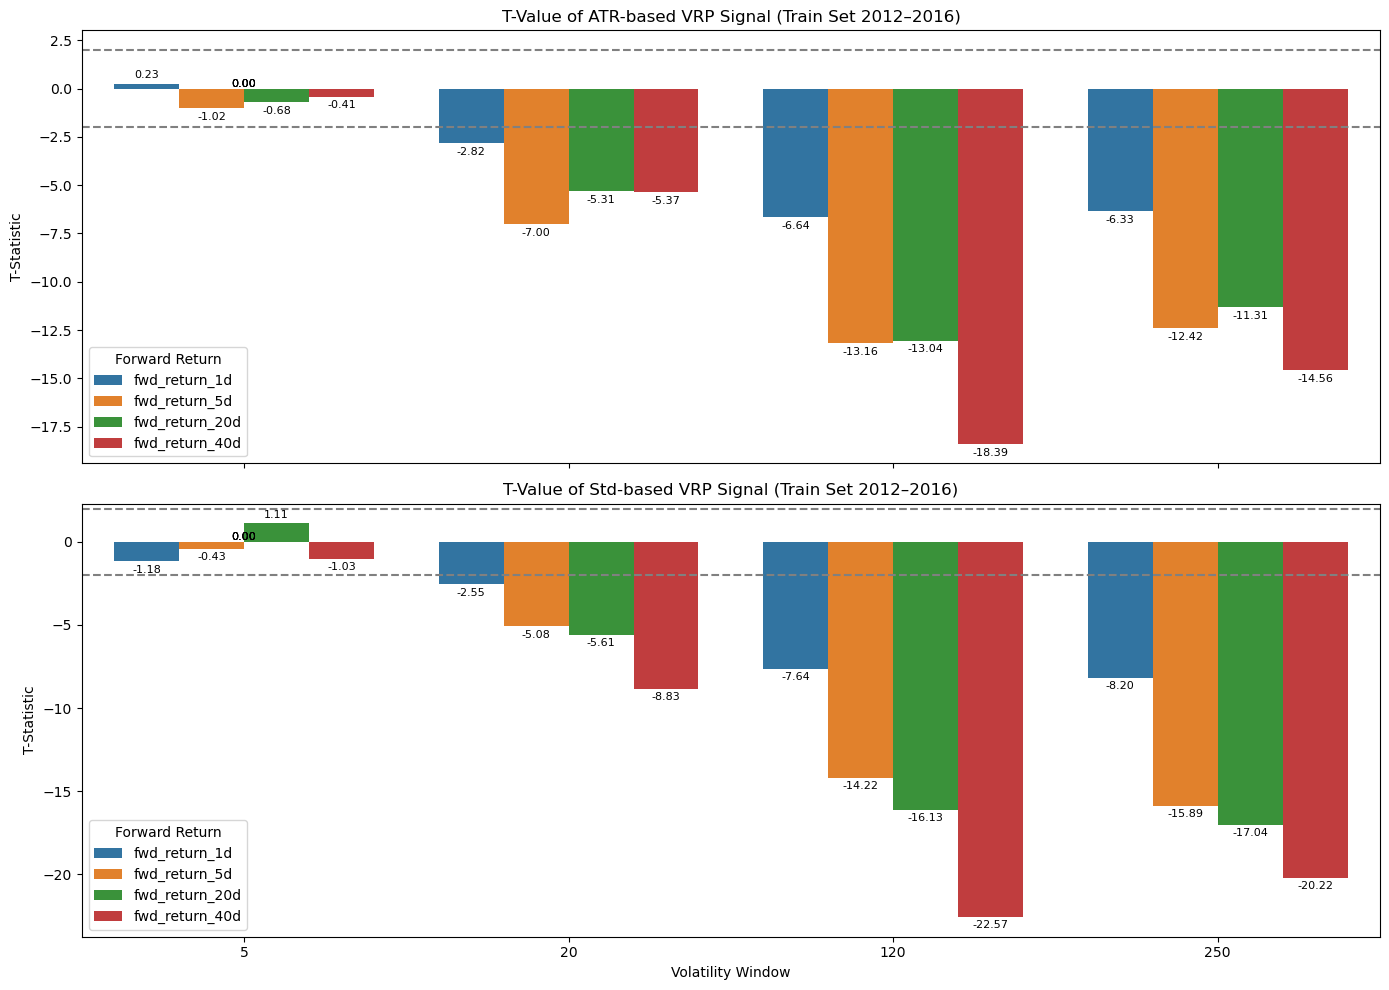

In [12]:
# Set the training period
train_df = df[(df['date'] >= "2012-01-01") & (df['date'] <= "2016-12-31")]

# Define forward return column names
forward_returns = [f"fwd_return_{d}d" for d in [1, 5, 20, 40]]

# Regression function for VRP signals
def run_vrp_regression(df, signal_prefix):
    """
    Runs univariate OLS regressions of forward returns on volatility mispricing signals.
    
    Parameters:
        df (DataFrame): Input data
        signal_prefix (str): e.g., 'vrp_atr' or 'vrp_std'

    Returns:
        DataFrame: t-values of the signal coefficients
    """
    signals = [f'{signal_prefix}_{n}' for n in [5, 20, 120, 250]]
    results = []
    for signal in signals:
        for target in forward_returns:
            if signal not in df.columns or target not in df.columns:
                continue
            temp_df = df[[signal, target]].dropna()
            if len(temp_df) < 100:
                continue
            X = sm.add_constant(temp_df[signal])
            y = temp_df[target]
            model = sm.OLS(y, X).fit()
            results.append({
                'signal': signal,
                'target': target,
                't_value': model.tvalues[signal]
            })
    result_df = pd.DataFrame(results)
    result_df['window'] = result_df['signal'].str.extract(r'_(\d+)$').astype(int)
    return result_df

# Run regressions
result_atr = run_vrp_regression(train_df, 'vrp_atr')
result_std = run_vrp_regression(train_df, 'vrp_std')

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for i, (result_df, label) in enumerate(zip(
    [result_atr, result_std],
    ['ATR-based VRP Signal', 'Std-based VRP Signal']
)):
    ax = axes[i]
    sns.barplot(data=result_df, x='window', y='t_value', hue='target', ax=ax)

    # Add t-value labels on bars
    for bar in ax.patches:
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        if not np.isnan(height):
            ax.text(x, height + 0.2 * np.sign(height), f"{height:.2f}",
                    ha='center', va='bottom' if height >= 0 else 'top', fontsize=8)

    # Add reference lines for statistical significance
    ax.axhline(2, color='gray', linestyle='--')
    ax.axhline(-2, color='gray', linestyle='--')
    ax.set_title(f"T-Value of {label} (Train Set 2012–2016)")
    ax.set_xlabel('Volatility Window')
    ax.set_ylabel('T-Statistic')
    ax.legend(title='Forward Return')

plt.tight_layout()
plt.show()

In [13]:
# 8. Combine and score ATR vs STD signals
# Concatenate ATR and STD results
combined_df = pd.concat([
    result_atr.assign(signal_type='ATR'),
    result_std.assign(signal_type='STD')
])

# Compute absolute t-values
combined_df['abs_t'] = combined_df['t_value'].abs()

# Aggregate by signal_type and window
summary_df = combined_df.groupby(['signal_type', 'window']).agg(
    min_abs_t=('abs_t', 'min'),
    mean_abs_t=('abs_t', 'mean')
).reset_index()

# Apply ranking logic: dense ranks for each metric, sum scores
summary_df['min_rank'] = summary_df['min_abs_t'].rank(method='dense', ascending=True)
summary_df['mean_rank'] = summary_df['mean_abs_t'].rank(method='dense', ascending=True)
summary_df['rank_score'] = summary_df['min_rank'] + summary_df['mean_rank']

# Tie-breaker: on equal rank_score pick highest mean_abs_t
max_score = summary_df['rank_score'].max()
candidates = summary_df[summary_df['rank_score'] == max_score]
best_summary = candidates.loc[candidates['mean_abs_t'].idxmax()]

# 9. Print best VRP signal configuration
print(f"Best VRP Signal Type: {best_summary['signal_type']}")
print(f"Best Volatility Window: {int(best_summary['window'])}")
print(f"  - Min |t|: {best_summary['min_abs_t']:.2f}")
print(f"  - Mean |t|: {best_summary['mean_abs_t']:.2f}")

Best VRP Signal Type: STD
Best Volatility Window: 250
  - Min |t|: 8.20
  - Mean |t|: 15.33


In [14]:
# Drop unnecessary columns related to intermediate volatility calculations and signals
cols_to_drop = [
    'prev_close', 'true_range',                    
    'atr_vol_5', 'atr_vol_20', 'atr_vol_120', 'atr_vol_250',    
    'vrp_atr_5', 'vrp_atr_20', 'vrp_atr_120', 'vrp_atr_250',     
    'std_vol_5', 'std_vol_20', 'std_vol_120', 'std_vol_250',     
    'vrp_std_5', 'vrp_std_20', 'vrp_std_120', 'CALL_IMP_VOL_30D'                     
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Invert the sign of the 250-day standard deviation VRP signal for directional alignment
df['vrp_std_250'] = -df['vrp_std_250']

# Display the first few rows of the cleaned DataFrame
df.head()


,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,DAY_TO_DAY_TOT_RETURN_GROSS_DVDS,CUR_MKT_CAP,IVOL_DELTA,IVOL_IMPLIED_FORWARD,fwd_return_1d,fwd_return_5d,fwd_return_20d,fwd_return_40d,daily_rf_return,vrp_std_250
0,2010-01-04,ACN,42.20,41.50,41.50,42.07,1122800.0,16.3173,10.6855,1.1719,1.3735,30755.6768,21.7763,41.9751,0.006178,0.010923,-0.010740,-0.034078,0.000002,NaN
1,2010-01-05,ACN,42.45,41.99,42.09,42.33,755600.0,16.4182,10.7516,1.1791,0.6180,30945.7523,21.7763,42.3300,0.010628,-0.001666,-0.017294,-0.033642,0.000002,NaN
2,2010-01-06,ACN,42.90,41.81,42.09,42.78,1361300.0,16.5927,10.8659,1.1916,1.0631,31274.7291,21.7763,42.7800,-0.000937,-0.000945,-0.050763,-0.037478,0.000002,NaN
3,2010-01-07,ACN,42.89,42.24,42.43,42.74,1402100.0,16.5772,10.8557,1.1905,-0.0935,31245.4867,25.3271,42.8503,-0.003979,0.008882,-0.051509,-0.030018,0.000002,NaN
4,2010-01-08,ACN,43.06,42.20,42.35,42.57,1363800.0,16.5112,10.8125,1.1858,-0.3978,31121.2066,23.5517,42.5700,-0.000941,0.005630,-0.056409,-0.012043,0.000002,NaN


## 3. Time-Series **Value Signal** Construction

### Step 1: Indices Choice

A set of valuation metrics is chosen as the basis for signal construction, including:

- **Price-to-Earnings ratio** (`PE_RATIO`)  
- **Price-to-Book ratio** (`PX_TO_BOOK_RATIO`)  
- **Price-to-Sales ratio** (`PX_TO_SALES_RATIO`)  

Each signal is computed using windows of **20, 60, 120, and 250 trading days** to capture short- to long-term historical context.

---

### Step 2: Restrict to In-Sample Training Period

The analysis focuses on the in-sample period from **January 1, 2012 to December 31, 2016**.  
This window is used to compute signals and estimate their in-sample explanatory power through regression.

---

### Step 3: Construct Time-Series Value Signals

Each valuation factor is transformed into a time-series signal using a **rolling percentile approach**:

- The latest observation is compared against its own past values within a rolling window.  
- The signal takes a value between **-1 and +1**, where:  
  - `+1` indicates the current valuation is at the **low end** of historical levels (**undervaluation**)  
  - `-1` indicates it is at the **high end** (**overvaluation**)  

This transformation is applied for each factor and each window size, for every stock individually.

---

### Step 4: Perform Cross-Sectional Regression

To evaluate predictive performance, **cross-sectional OLS regressions** are conducted:

- The **dependent variable** is the forward return of stocks.  
- The **independent variable** is the corresponding signal value for each stock on that day.  
- The regression estimates relationships **across stocks**.

The **t-statistic** of the signal coefficient is recorded, measuring the statistical significance of each signal's predictive power.

---

### Step 5: Aggregate Results

All t-statistics across different:

- valuation signals  
- rolling window lengths  
- and prediction horizons  

are collected into a structured table.  
Each row corresponds to a unique combination of factor, window, and return horizon.

---

### Step 6: Visualize Statistical Significance

The t-statistics are visualized using **bar charts** to compare the predictive power of different signals:

- One subplot is created for **each valuation factor**  
- Within each subplot, bars represent **t-values** for signals with different **rolling window sizes**  
- Bars are **grouped by forward return horizon**, allowing comparison of short-term vs. long-term predictability  
- Horizontal **dashed lines at ±2** mark conventional significance thresholds

## Chart Analysis

Bar charts show t-statistics from cross-sectional regressions of forward returns on rolling valuation signals.  
Each subplot corresponds to a different valuation factor (`PE_RATIO`, `PX_TO_BOOK_RATIO`, `PX_TO_SALES_RATIO`),  
evaluated across four rolling window sizes (20, 60, 120, 250 days) and four return horizons (1d, 5d, 20d, 40d).  
Dashed lines at ±2 indicate statistical significance thresholds.

---

### Factor: PE_RATIO

- T-statistics are significantly negative across all settings.
- Strongest performance at 60-day window.
- Mean $|t|$: 17.97, min $|t|$: 7.26.

Selected window:  
- Rolling window: 60 days  
- Signal direction: multiply by -1

---

### Factor: PX_TO_BOOK_RATIO

- Significant but weaker than PE.
- Strongest at 60-day window.
- Mean $|t|$: 13.89, min $|t|$: 4.99.

Selected window:  
- Rolling window: 60 days  
- Signal direction: multiply by -1

---

### Factor: PX_TO_SALES_RATIO

- Strong predictive power across all horizons.
- Peak at 60-day window.
- Mean $|t|$: 15.71, min $|t|$: 6.30.

Selected window:  
- Rolling window: 60 days  
- Signal direction: multiply by -1

---

### Final Selected Window Table

| Valuation Factor     | Rolling Window | Signal Direction |
|----------------------|----------------|------------------|
| PE_RATIO             | 60 days        | -1               |
| PX_TO_BOOK_RATIO     | 60 days        | -1               |
| PX_TO_SALES_RATIO    | 60 days        | -1               |


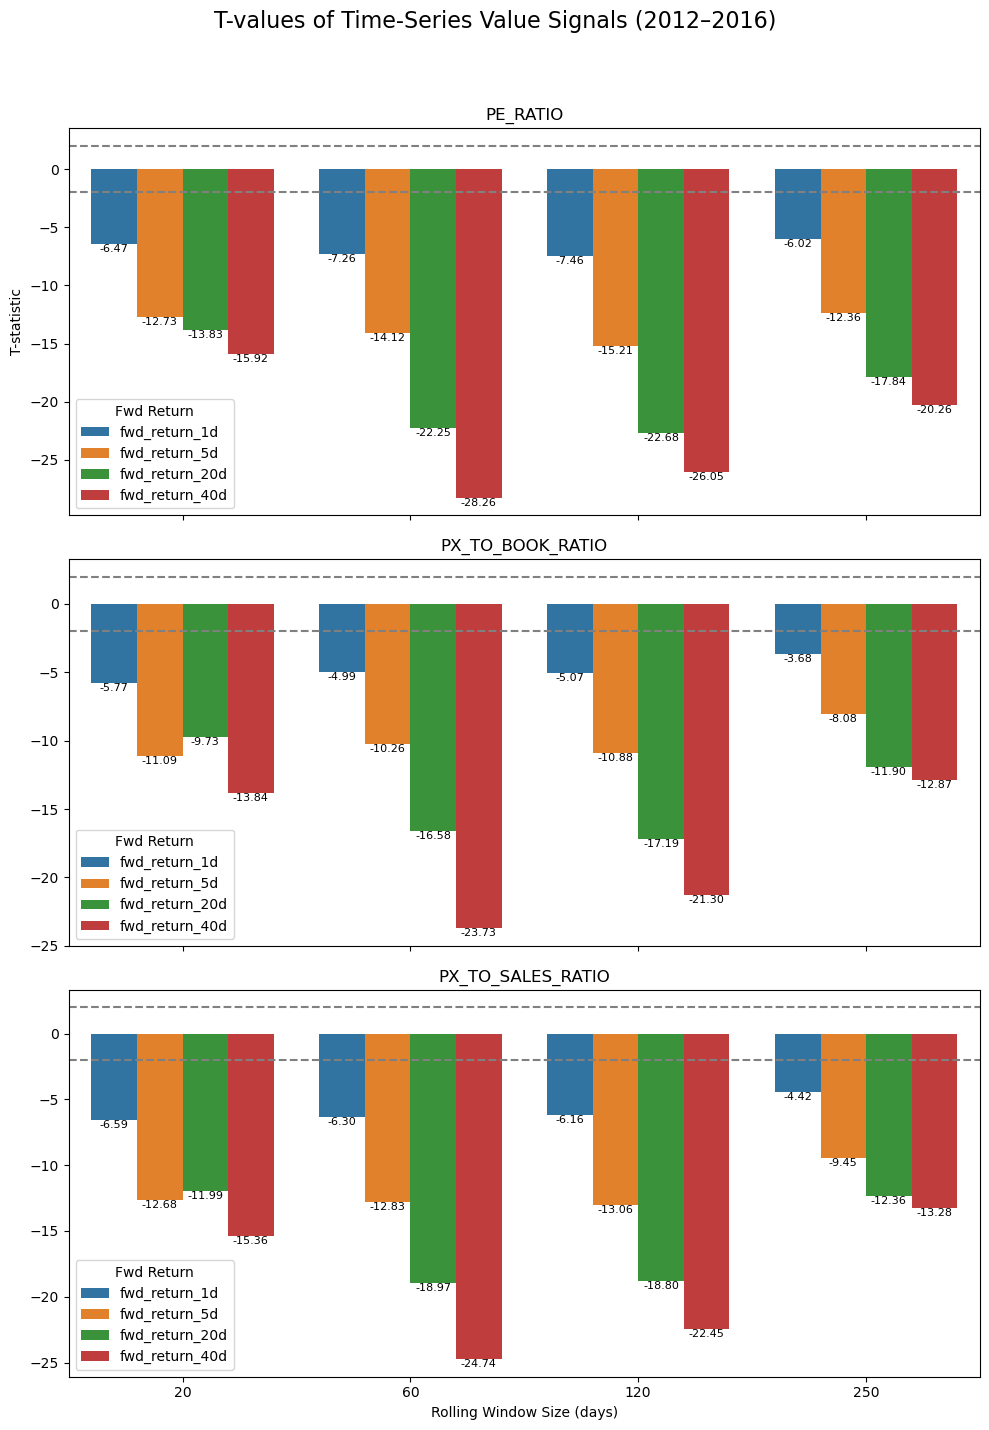

In [15]:
# Define forward return columns for different holding periods
forward_returns = [f"fwd_return_{d}d" for d in [1, 5, 20, 40]]

# Set rolling window sizes for signal construction
value_windows = [20, 60, 120, 250]

# Specify valuation factors to be used
value_factors = ['PE_RATIO', 'PX_TO_BOOK_RATIO', 'PX_TO_SALES_RATIO']

# Construct rolling time-series signals across the full dataset
# Each signal is normalized to the range [-1, 1] based on historical rank
for factor in value_factors:
    for window in value_windows:
        signal_col = f"{factor}_signal_{window}"
        df[signal_col] = df.groupby('ticker')[factor].transform(
            lambda x: x.rolling(window, min_periods=window // 2).apply(
                lambda y: 2 * ((y < y.iloc[-1]).mean()) - 1
            )
        )

# Extract training period (in-sample window) for regression analysis
train_df = df[(df['date'] >= "2012-01-01") & (df['date'] <= "2016-12-31")].copy()

# Define cross-sectional regression function
# For each forward return column, regress it on a given signal
# Record the t-statistic of the signal coefficient
def run_cross_sectional_regression(df, signal_col, target_cols):
    result_rows = []
    for target in target_cols:
        temp_df = df[[signal_col, target]].dropna()
        if len(temp_df) < 100:
            continue
        X = sm.add_constant(temp_df[signal_col])
        y = temp_df[target]
        model = sm.OLS(y, X).fit()
        result_rows.append({
            'signal': signal_col,
            'factor': signal_col.split('_signal_')[0],
            'window': int(signal_col.split('_signal_')[1]),
            'target': target,
            't_value': model.tvalues[signal_col]
        })
    return result_rows

# Run cross-sectional regressions for all factor-window combinations
all_results = []
for factor in value_factors:
    for window in value_windows:
        signal_col = f"{factor}_signal_{window}"
        result = run_cross_sectional_regression(train_df, signal_col, forward_returns)
        all_results.extend(result)

# Convert regression results to a DataFrame
cs_result = pd.DataFrame(all_results)

# Visualize the t-statistics for each signal across window lengths and return horizons
fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

for i, factor in enumerate(value_factors):
    ax = axs[i]
    plot_data = cs_result[cs_result['factor'] == factor]
    sns.barplot(data=plot_data, x='window', y='t_value', hue='target', ax=ax, errorbar=None)

    # Annotate bars with actual t-statistic values
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type='edge', fontsize=8)

    # Add reference lines for statistical significance
    ax.axhline(2, ls='--', color='gray')
    ax.axhline(-2, ls='--', color='gray')
    ax.set_title(f"{factor}")
    ax.set_xlabel("Rolling Window Size (days)")
    if i == 0:
        ax.set_ylabel("T-statistic")
    else:
        ax.set_ylabel("")
    ax.legend().set_title("Fwd Return")

plt.suptitle("T-values of Time-Series Value Signals (2012–2016)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [16]:
# Compute absolute t-statistics
cs_result['abs_t'] = cs_result['t_value'].abs()

best_windows = []        # Store best window for each factor
all_rank_tables = []     # Store full rank info for all factors

for factor in value_factors:
    # Filter by factor
    sub_df = cs_result[cs_result['factor'] == factor]

    # Aggregate min and mean |t| by window
    agg_df = (
        sub_df
        .groupby('window')['abs_t']
        .agg(min_abs_t='min', mean_abs_t='mean')
        .reset_index()
    )

    # Rank by ascending order (smallest gets 1)
    agg_df['min_rank'] = agg_df['min_abs_t'].rank(method='dense', ascending=True)
    agg_df['mean_rank'] = agg_df['mean_abs_t'].rank(method='dense', ascending=True)

    # Total score = sum of ranks
    agg_df['rank_score'] = agg_df['min_rank'] + agg_df['mean_rank']

    # Tie-breaker: if rank_score ties, pick window with highest mean_abs_t
    # 1. Find max score
    max_score = agg_df['rank_score'].max()
    # 2. Filter candidates with max_score
    candidates = agg_df[agg_df['rank_score'] == max_score]
    # 3. Select the candidate with highest mean_abs_t
    best = candidates.loc[candidates['mean_abs_t'].idxmax()]

    # Store best window info
    best_windows.append({
        'factor': factor,
        'best_window': int(best['window']),
        'min_abs_t': best['min_abs_t'],
        'mean_abs_t': best['mean_abs_t'],
        'rank_score': int(best['rank_score'])
    })
    agg_df['factor'] = factor
    all_rank_tables.append(agg_df)

# Combine results
best_windows_df = pd.DataFrame(best_windows)
rank_table_df = pd.concat(all_rank_tables, ignore_index=True)

# Print best window summary
for _, row in best_windows_df.iterrows():
    print(f"Factor: {row['factor']}")
    print(f"  Best Window: {row['best_window']} days")
    print(f"  Min |t|: {row['min_abs_t']:.2f}")
    print(f"  Mean |t|: {row['mean_abs_t']:.2f}")
    print(f"  Rank Score: {row['rank_score']}")
    print('-' * 40)


Factor: PE_RATIO
  Best Window: 60 days
  Min |t|: 7.26
  Mean |t|: 17.97
  Rank Score: 7
----------------------------------------
Factor: PX_TO_BOOK_RATIO
  Best Window: 60 days
  Min |t|: 4.99
  Mean |t|: 13.89
  Rank Score: 6
----------------------------------------
Factor: PX_TO_SALES_RATIO
  Best Window: 60 days
  Min |t|: 6.30
  Mean |t|: 15.71
  Rank Score: 7
----------------------------------------


In [17]:
# List of all signal columns
all_signals = [
    'PE_RATIO_signal_20', 'PE_RATIO_signal_60', 'PE_RATIO_signal_120', 'PE_RATIO_signal_250',
    'PX_TO_BOOK_RATIO_signal_20', 'PX_TO_BOOK_RATIO_signal_60', 'PX_TO_BOOK_RATIO_signal_120', 'PX_TO_BOOK_RATIO_signal_250',
    'PX_TO_SALES_RATIO_signal_20', 'PX_TO_SALES_RATIO_signal_60', 'PX_TO_SALES_RATIO_signal_120', 'PX_TO_SALES_RATIO_signal_250'
]

# Keep only the selected signal columns based on updated best windows
selected_signals = ['PE_RATIO_signal_60', 'PX_TO_BOOK_RATIO_signal_60', 'PX_TO_SALES_RATIO_signal_60']

# Multiply selected signal columns by -1 in place
for col in selected_signals:
    df[col] = -df[col]

# Drop all unused signal columns
cols_to_drop = [col for col in all_signals if col not in selected_signals]
df.drop(columns=cols_to_drop, inplace=True)

In [18]:
df.tail()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,...,IVOL_IMPLIED_FORWARD,fwd_return_1d,fwd_return_5d,fwd_return_20d,fwd_return_40d,daily_rf_return,vrp_std_250,PE_RATIO_signal_60,PX_TO_BOOK_RATIO_signal_60,PX_TO_SALES_RATIO_signal_60
127369,2020-12-24,WFC,30.350,29.665,30.35,29.84,2961029.0,46.6354,0.7704,1.4291,...,29.8443,0.003013,-0.004708,0.051544,0.283048,0.000003,-0.483048,-0.933333,-0.933333,-0.933333
127370,2020-12-28,WFC,30.475,29.910,30.05,29.93,4327450.0,46.7761,0.7727,1.4334,...,29.9535,-0.005015,0.020030,0.007952,0.254795,0.000003,-0.406522,-0.933333,-0.933333,-0.933333
127371,2020-12-29,WFC,30.165,29.750,30.10,29.78,4343416.0,46.5416,0.7688,1.4262,...,29.8685,-0.001011,0.097699,0.034519,0.214437,0.000003,-0.429896,-0.866667,-0.866667,-0.866667
127372,2020-12-30,WFC,30.040,29.655,29.80,29.75,4007378.0,46.4948,0.7680,1.4248,...,29.8431,0.014451,0.123683,0.004313,0.246610,0.000003,-0.449142,-0.833333,-0.833333,-0.833333
127373,2020-12-31,WFC,30.231,29.680,29.75,30.18,5096866.0,58.7160,0.7683,1.5197,...,30.2030,-0.015907,0.099723,-0.006342,0.230524,0.000002,-0.420819,-0.966667,-0.833333,-0.966667


## 4. EWMA-Based Trend Signal

Measures the relative deviation of the current price from its exponentially weighted moving average (EWMA), serving as a proxy for trend signal.

---

### EWMA Definition

For each stock $i$ at time $t$, the EWMA of the price is defined as:

$$
\text{EWMA}_{i,t}^{(\lambda)} = \sum_{k=0}^{\infty} (1 - \alpha)^k \cdot P_{i,t-k}, \quad \text{where} \quad \alpha = \frac{2}{\lambda + 1}
$$

Where:

- $P_{i,t}$ is the closing price at time $t$  
- $\lambda$ is the smoothing span (5, 20, 60, 120, 250)

---

### Trend Signal Formula

The signal is defined as the normalized deviation from EWMA:

$$
\text{Signal}_{i,t}^{(\lambda)} = \frac{P_{i,t}}{\text{EWMA}_{i,t}^{(\lambda)}} - 1
$$

Where:

- $\text{Signal}_{i,t} > 0$ implies price is above trend  
- $\text{Signal}_{i,t} < 0$ implies price is below trend

## Chart Analysis

Pooled cross-sectional regression results show that EWMA-based trend signals produce consistently negative coefficients across all return horizons (1d, 5d, 20d, 40d).  
This indicates a clear mean-reversion effect: higher price deviations from trend are associated with lower subsequent returns.

T-statistics increase in magnitude with longer EWMA spans, reaching the strongest values at the 60-day span.  
This configuration achieves the highest average statistical significance across horizons.

- **Minimum $|t|$**: 5.68  
- **Mean $|t|$**: 11.82  
- **Rank Score**: 9

---

### Final Signal Configuration

- Signal type: EWMA-based trend  
- EWMA span: 60 days  
- Signal direction: negative

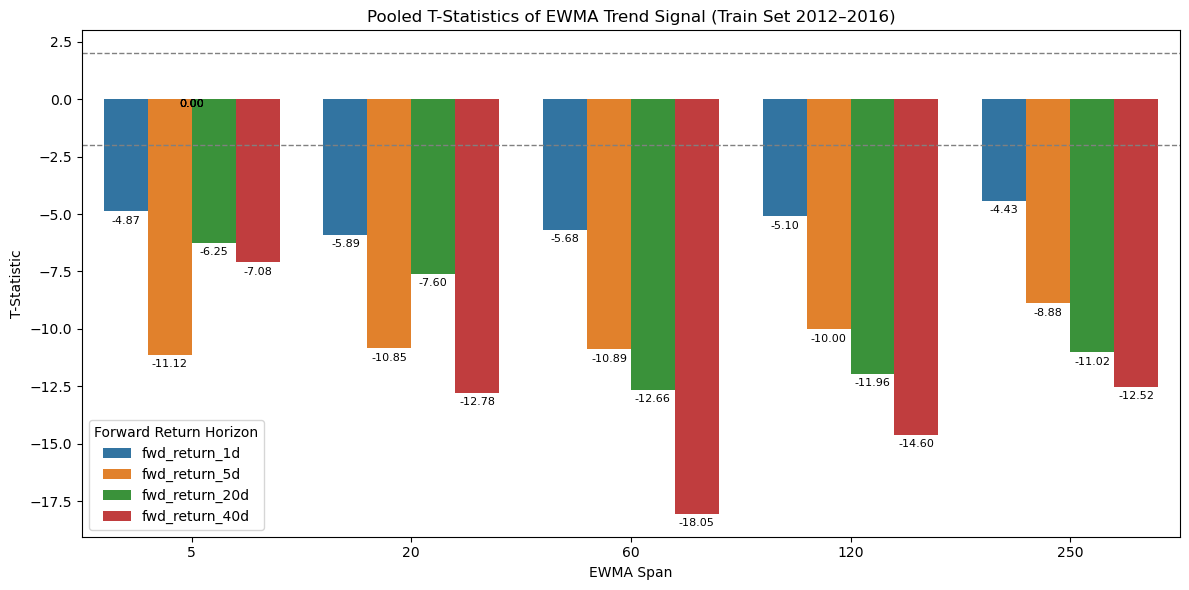

In [19]:
# 1. Construct EWMA-based trend signals
ewma_spans = [5, 20, 60, 120, 250]

for span in ewma_spans:
    ewma_col = f'PX_LAST_ewma_span{span}'
    signal_col = f'PX_LAST_trend_signal_span{span}'

    # Compute EWMA price for each ticker
    df[ewma_col] = df.groupby('ticker')['PX_LAST'].transform(lambda x: x.ewm(span=span, adjust=False).mean())

    # Compute signal: relative deviation from EWMA (price - EWMA) / EWMA
    df[signal_col] = df['PX_LAST'] / df[ewma_col] - 1  # continuous signal

# 2. Define training set
train_df = df[(df['date'] >= '2012-01-01') & (df['date'] <= '2016-12-31')].copy()

# 3. Run pooled regression for each span × forward return
forward_returns = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d']
results = []

for span in ewma_spans:
    signal_col = f'PX_LAST_trend_signal_span{span}'

    for ret_col in forward_returns:
        temp_df = train_df[[signal_col, ret_col]].dropna()

        # Define regression inputs
        X = sm.add_constant(temp_df[signal_col])
        y = temp_df[ret_col]

        try:
            model = sm.OLS(y, X).fit()
            t_val = model.tvalues[signal_col]
            results.append({
                'window': span,
                'target': ret_col,
                't_value': t_val,
                'coef': model.params[signal_col]
            })
        except:
            continue

# Convert to DataFrame
result_df = pd.DataFrame(results)

# 4. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=result_df, x='window', y='t_value', hue='target')

# Annotate bars with t-values
for bar in plt.gca().patches:
    height = bar.get_height()
    if not np.isnan(height):
        x = bar.get_x() + bar.get_width() / 2
        plt.text(x, height + 0.2 * np.sign(height), f"{height:.2f}",
                 ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

# Significance reference lines
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

plt.title("Pooled T-Statistics of EWMA Trend Signal (Train Set 2012–2016)")
plt.xlabel("EWMA Span")
plt.ylabel("T-Statistic")
plt.legend(title="Forward Return Horizon")
plt.tight_layout()
plt.show()

In [20]:
# Select best window based on min/mean |t| ranking, with tie-break on mean
result_df['abs_t'] = result_df['t_value'].abs()
rank_df = (
    result_df
    .groupby('window')['abs_t']
    .agg(min_abs_t='min', mean_abs_t='mean')
    .reset_index()
)

# Dense ranks (ascending: smaller value → smaller rank number), then sum
rank_df['min_rank'] = rank_df['min_abs_t'].rank(method='dense', ascending=True)
rank_df['mean_rank'] = rank_df['mean_abs_t'].rank(method='dense', ascending=True)
rank_df['rank_score'] = rank_df['min_rank'] + rank_df['mean_rank']

# Pick max rank_score; tie-break by highest mean_abs_t
max_score = rank_df['rank_score'].max()
candidates = rank_df[rank_df['rank_score'] == max_score]
best_row = candidates.loc[candidates['mean_abs_t'].idxmax()]

print(f"Best EWMA Trend Span: {int(best_row['window'])} days")
print(f"  - Min |t|: {best_row['min_abs_t']:.2f}")
print(f"  - Mean |t|: {best_row['mean_abs_t']:.2f}")
print(f"  - Rank Score: {int(best_row['rank_score'])}")

Best EWMA Trend Span: 60 days
  - Min |t|: 5.68
  - Mean |t|: 11.82
  - Rank Score: 9


In [21]:
# Columns to drop
columns_to_drop = [
    'PX_LAST_ewma_span5',
    'PX_LAST_trend_signal_span5',
    'PX_LAST_ewma_span20',
    'PX_LAST_trend_signal_span20',
    'PX_LAST_ewma_span120',
    'PX_LAST_trend_signal_span120',
    'PX_LAST_ewma_span250',
    'PX_LAST_trend_signal_span250',
    'PX_LAST_ewma_span60',
    'PX_LAST_trend_signal_span60'
]



# Flip the span=60 signal
df['PX_LAST_EWMA_signal_span60'] = -df['PX_LAST_trend_signal_span60']
# Drop them from the dataframe
df.drop(columns=columns_to_drop, inplace=True)

df.head()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,...,fwd_return_1d,fwd_return_5d,fwd_return_20d,fwd_return_40d,daily_rf_return,vrp_std_250,PE_RATIO_signal_60,PX_TO_BOOK_RATIO_signal_60,PX_TO_SALES_RATIO_signal_60,PX_LAST_EWMA_signal_span60
0,2010-01-04,ACN,42.20,41.50,41.50,42.07,1122800.0,16.3173,10.6855,1.1719,...,0.006178,0.010923,-0.010740,-0.034078,0.000002,NaN,NaN,NaN,NaN,-0.000000
1,2010-01-05,ACN,42.45,41.99,42.09,42.33,755600.0,16.4182,10.7516,1.1791,...,0.010628,-0.001666,-0.017294,-0.033642,0.000002,NaN,NaN,NaN,NaN,-0.005976
2,2010-01-06,ACN,42.90,41.81,42.09,42.78,1361300.0,16.5927,10.8659,1.1916,...,-0.000937,-0.000945,-0.050763,-0.037478,0.000002,NaN,NaN,NaN,NaN,-0.016115
3,2010-01-07,ACN,42.89,42.24,42.43,42.74,1402100.0,16.5772,10.8557,1.1905,...,-0.003979,0.008882,-0.051509,-0.030018,0.000002,NaN,NaN,NaN,NaN,-0.014661
4,2010-01-08,ACN,43.06,42.20,42.35,42.57,1363800.0,16.5112,10.8125,1.1858,...,-0.000941,0.005630,-0.056409,-0.012043,0.000002,NaN,NaN,NaN,NaN,-0.010273


## EWMA Acceleration Signal

This section evaluates the **EWMA-based acceleration signal**, defined as the rate of change in the EWMA of prices.  
The signal is designed to capture short-term momentum or deceleration in smoothed trends.

---

### Signal Construction

The acceleration signal is computed as the **percentage change** in EWMA from one day to the next, across multiple EWMA spans (5, 20, 60, 120, 250).  
Each signal is calculated per stock to preserve time-series dynamics.

---

### Regression Evaluation

To assess the predictive power of the acceleration signals, **pooled cross-sectional OLS regressions** are conducted using data from the in-sample period (2012–2016).  
Each regression estimates the relationship between the acceleration signal and forward returns over multiple horizons (1d, 5d, 20d, 40d).  
The **t-statistics** of the signal coefficients are recorded to evaluate statistical significance.

---

### Visualization Summary

A bar chart is used to display the t-statistics for each EWMA span and return horizon.  
Horizontal dashed lines at ±2 mark conventional significance thresholds.  
Text annotations indicate the exact t-values for clarity.

---

### **Conclusion**

The acceleration signal shows a **pattern similar to the basic EWMA trend signal**, with no material improvement in predictive power.  
Due to this redundancy and lack of added value, **the EWMA acceleration signal is not included in the final modeling dataset**.

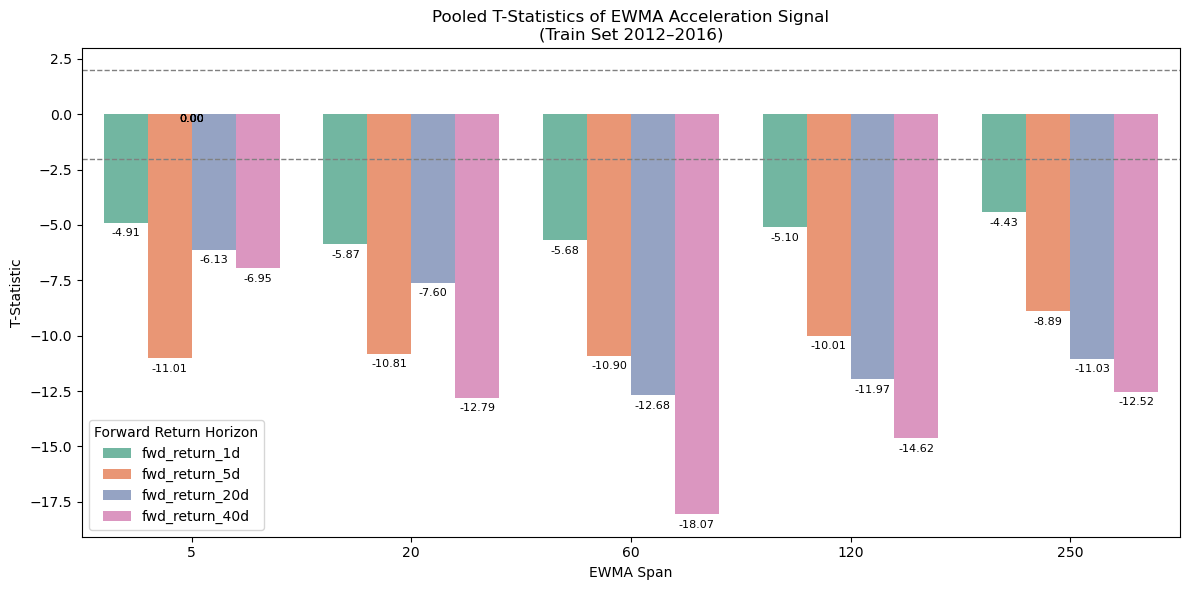

In [22]:
# 1. Set parameters
ewma_spans = [5, 20, 60, 120, 250]
forward_returns = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d']

# 2. Copy original data
df_trend = df.copy()

# 3. Compute EWMA and acceleration
for span in ewma_spans:
    ewma_col = f'ewma_s{span}'
    accel_col = f'accel_s{span}'
    
    df_trend[ewma_col] = df_trend.groupby('ticker')['PX_LAST'].transform(
        lambda x: x.ewm(span=span, adjust=False).mean()
    )
    df_trend[accel_col] = df_trend.groupby('ticker')[ewma_col].transform(
        lambda x: x.diff() / x.shift()
    )
    df_trend[accel_col] = df_trend[accel_col].fillna(0)

# 4. Select training set
train_df = df_trend[(df_trend['date'] >= '2012-01-01') & (df_trend['date'] <= '2016-12-31')].copy()

# 5. Run pooled regressions
results = []

for span in ewma_spans:
    accel_col = f'accel_s{span}'

    for ret_col in forward_returns:
        temp_df = train_df[[accel_col, ret_col]].dropna()
        if len(temp_df) == 0:
            continue
        X = sm.add_constant(temp_df[accel_col])
        y = temp_df[ret_col]
        model = sm.OLS(y, X).fit()
        results.append({
            'span': span,
            'target': ret_col,
            't_value': model.tvalues[accel_col],
            'coef': model.params[accel_col]
        })

# 6. Store results
accel_df = pd.DataFrame(results)

# 7. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=accel_df, x='span', y='t_value', hue='target', palette='Set2')

# Add text annotations on bars
for bar in plt.gca().patches:
    height = bar.get_height()
    if not np.isnan(height):
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.25 * np.sign(height),
                 f"{height:.2f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

# Add horizontal lines at ±2
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

plt.title("Pooled T-Statistics of EWMA Acceleration Signal\n(Train Set 2012–2016)")
plt.xlabel("EWMA Span")
plt.ylabel("T-Statistic")
plt.legend(title="Forward Return Horizon")
plt.tight_layout()
plt.show()

## 6. EWMA Crossover Signal Construction

To capture how short-term and long-term trends differ, this signal compares a short-term EWMA ("fast") to a long-term EWMA ("slow").  
It shows how much the fast-moving average is above or below the slow one.

---

### Signal Definition

For each stock $i$ at time $t$, the EWMA crossover signal is:

$$
\text{Signal}_{i,t}^{(f,s)} = \frac{\text{EWMA}_{i,t}^{(f)} - \text{EWMA}_{i,t}^{(s)}}{\text{EWMA}_{i,t}^{(s)}}
$$

Where:

- $f$ is the **short-term EWMA** span  
- $s$ is the **long-term EWMA** span  
- $\text{EWMA}_{i,t}^{(f)}$ is the exponential moving average of price $P_{i,t}$ using span $f$

The signal is normalized by the slow EWMA so it can be compared across different stocks and price levels.

---

### EWMA Span Combinations

Signals are built using the following span pairs:

- Short-term spans: $f \in \{5, 20, 60\}$  
- Long-term spans: $s \in \{80, 120, 250\}$

This gives **9 crossover signals**, such as:

- `ewma_crossover_5_80_normalized`  
- `ewma_crossover_5_120_normalized`  
- `ewma_crossover_5_250_normalized`  
- ...  
- `ewma_crossover_60_250_normalized`

## Chart Analysis

T-statistics from pooled cross-sectional regressions are negative across all fast/slow EWMA span combinations and forward return horizons.  
This reflects a **mean-reversion** relationship: higher values of the crossover signal are associated with lower subsequent returns.

The **5/80** configuration delivers the strongest and most consistent t-statistics, especially at 20-day and 40-day forward return horizons.  
This setting captures short-term deviations relative to a medium-term trend.

- **Minimum $|t|$**: 4.90  
- **Mean $|t|$**: 10.75  
- **Rank Score**: 18

---

### Final Signal Configuration

- Signal type: normalized EWMA crossover  
- Fast span: 5 days  
- Slow span: 80 days  
- Signal direction: negative

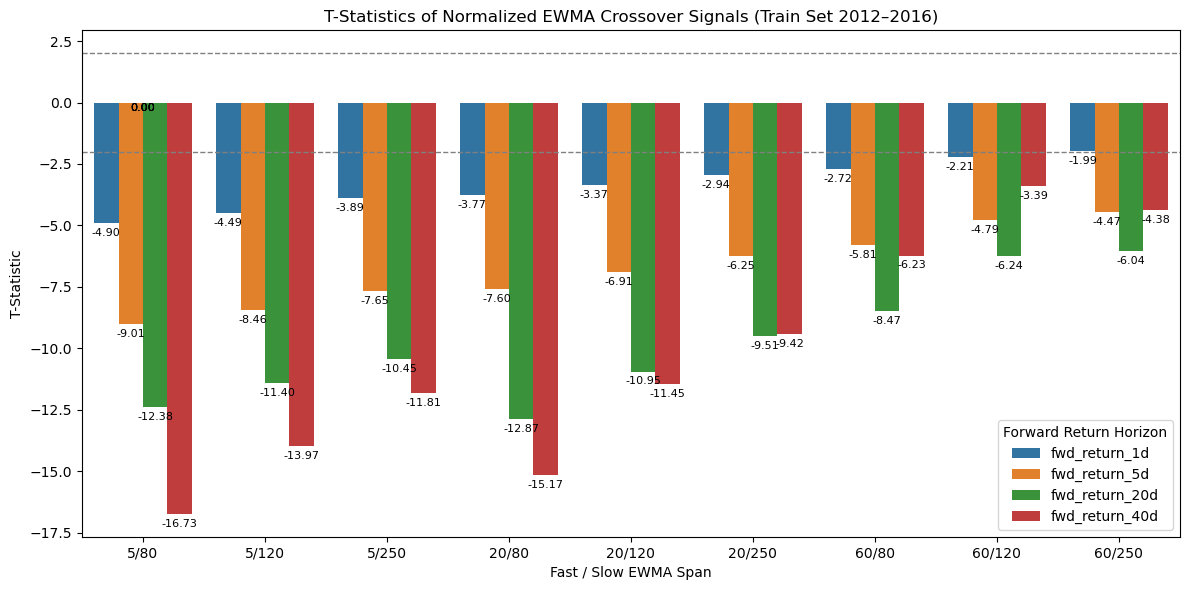

In [23]:
# 1. Construct normalized EWMA crossover signals
fast_spans = [5, 20, 60]
slow_spans = [80, 120, 250]

# Compute all needed EWMA columns on the full df
for span in set(fast_spans + slow_spans):
    df[f'PX_LAST_ewma_span{span}'] = df.groupby('ticker')['PX_LAST'].transform(
        lambda x: x.ewm(span=span, adjust=False).mean()
    )

# Create normalized crossover signals
for fast in fast_spans:
    for slow in slow_spans:
        fast_col = f'PX_LAST_ewma_span{fast}'
        slow_col = f'PX_LAST_ewma_span{slow}'
        signal_col = f'ewma_crossover_{fast}_{slow}_normalized'

        # (fast - slow) / slow
        df[signal_col] = (df[fast_col] - df[slow_col]) / df[slow_col]

# 2. Define training set
train_df = df[(df['date'] >= '2012-01-01') & (df['date'] <= '2016-12-31')].copy()

# 3. Run pooled regression: each signal × each forward return
forward_returns = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d']
results = []

for fast in fast_spans:
    for slow in slow_spans:
        signal_col = f'ewma_crossover_{fast}_{slow}_normalized'
        for ret_col in forward_returns:
            temp_df = train_df[[signal_col, ret_col]].dropna()
            if len(temp_df) < 100:
                continue

            X = sm.add_constant(temp_df[signal_col])
            y = temp_df[ret_col]
            try:
                model = sm.OLS(y, X).fit()
                t_val = model.tvalues[signal_col]
                results.append({
                    'fast': fast,
                    'slow': slow,
                    'signal': signal_col,
                    'target': ret_col,
                    't_value': t_val
                })
            except:
                continue

# 4. Visualization
result_df = pd.DataFrame(results)
result_df['pair'] = result_df['fast'].astype(str) + '/' + result_df['slow'].astype(str)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=result_df, x='pair', y='t_value', hue='target')

# Annotate each bar
for bar in ax.patches:
    height = bar.get_height()
    if not np.isnan(height):
        x = bar.get_x() + bar.get_width() / 2
        ax.text(x, height + 0.2 * np.sign(height), f"{height:.2f}",
                ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

# Add significance lines
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

plt.title("T-Statistics of Normalized EWMA Crossover Signals (Train Set 2012–2016)")
plt.xlabel("Fast / Slow EWMA Span")
plt.ylabel("T-Statistic")
plt.legend(title="Forward Return Horizon")
plt.tight_layout()
plt.show()

In [24]:
# Select best EWMA crossover window (fast/slow pair) using min/mean |t| ranking
result_df = pd.DataFrame(results)
if not result_df.empty:
    result_df['abs_t'] = result_df['t_value'].abs()

    # Aggregate by (fast, slow) pair across all forward horizons
    rank_df = (
        result_df
        .groupby(['fast', 'slow'])['abs_t']
        .agg(min_abs_t='min', mean_abs_t='mean')
        .reset_index()
    )

    # Dense ranks (ascending), sum scores
    rank_df['min_rank'] = rank_df['min_abs_t'].rank(method='dense', ascending=True)
    rank_df['mean_rank'] = rank_df['mean_abs_t'].rank(method='dense', ascending=True)
    rank_df['rank_score'] = rank_df['min_rank'] + rank_df['mean_rank']

    # Pick maximum rank_score; tie-break by highest mean_abs_t
    max_score = rank_df['rank_score'].max()
    candidates = rank_df[rank_df['rank_score'] == max_score]
    best_row = candidates.loc[candidates['mean_abs_t'].idxmax()]

    print(f"Best EWMA Crossover (fast/slow): {int(best_row['fast'])}/{int(best_row['slow'])}")
    print(f"  - Min |t|: {best_row['min_abs_t']:.2f}")
    print(f"  - Mean |t|: {best_row['mean_abs_t']:.2f}")
    print(f"  - Rank Score: {int(best_row['rank_score'])}")

Best EWMA Crossover (fast/slow): 5/80
  - Min |t|: 4.90
  - Mean |t|: 10.75
  - Rank Score: 18


In [25]:
# Drop all unused crossover columns (except 5/80)
crossover_to_drop = [
    'ewma_crossover_5_120_normalized',
    'ewma_crossover_5_250_normalized',
    'ewma_crossover_20_80_normalized',
    'ewma_crossover_20_120_normalized',
    'ewma_crossover_20_250_normalized',
    'ewma_crossover_60_80_normalized',
    'ewma_crossover_60_120_normalized',
    'ewma_crossover_60_250_normalized',
    'PX_LAST_ewma_span5',
    'PX_LAST_ewma_span80',
    'PX_LAST_ewma_span20',
    'PX_LAST_ewma_span120',
    'PX_LAST_ewma_span250',
    'PX_LAST_ewma_span60'
]

df.drop(columns=crossover_to_drop, inplace=True)

# Create final signal and drop the original version
df['crossover_signal'] = -df['ewma_crossover_5_80_normalized']
df.drop(columns=['ewma_crossover_5_80_normalized'], inplace=True)
df.head()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,...,fwd_return_5d,fwd_return_20d,fwd_return_40d,daily_rf_return,vrp_std_250,PE_RATIO_signal_60,PX_TO_BOOK_RATIO_signal_60,PX_TO_SALES_RATIO_signal_60,PX_LAST_EWMA_signal_span60,crossover_signal
0,2010-01-04,ACN,42.20,41.50,41.50,42.07,1122800.0,16.3173,10.6855,1.1719,...,0.010923,-0.010740,-0.034078,0.000002,NaN,NaN,NaN,NaN,-0.000000,-0.000000
1,2010-01-05,ACN,42.45,41.99,42.09,42.33,755600.0,16.4182,10.7516,1.1791,...,-0.001666,-0.017294,-0.033642,0.000002,NaN,NaN,NaN,NaN,-0.005976,-0.001907
2,2010-01-06,ACN,42.90,41.81,42.09,42.78,1361300.0,16.5927,10.8659,1.1916,...,-0.000945,-0.050763,-0.037478,0.000002,NaN,NaN,NaN,NaN,-0.016115,-0.006430
3,2010-01-07,ACN,42.89,42.24,42.43,42.74,1402100.0,16.5772,10.8557,1.1905,...,0.008882,-0.051509,-0.030018,0.000002,NaN,NaN,NaN,NaN,-0.014661,-0.009021
4,2010-01-08,ACN,43.06,42.20,42.35,42.57,1363800.0,16.5112,10.8125,1.1858,...,0.005630,-0.056409,-0.012043,0.000002,NaN,NaN,NaN,NaN,-0.010273,-0.009385


## 7. Momentum Signal: Classic Breakout Signal

This section evaluates the predictive ability of a **classic breakout signal** on future stock returns using a training sample from 2012 to 2016.  
The analysis follows a recursive signal construction rule based on recent **highs and lows** over long and short windows, followed by **cross-sectional regressions** of future returns on the breakout signals.

---

### 1. Breakout Signal Construction

The breakout signal is defined recursively using two rolling windows:

- $\mu$: long-term window  
- $\lambda$: short-term window  

At each time $t$, the signal $b_t$ is updated according to the following rule:

$$
b_t =
\begin{cases}
1, & \text{if } P_t = \max(P_{t-\mu+1}, \dots, P_t) \\
-1, & \text{if } P_t = \min(P_{t-\mu+1}, \dots, P_t) \\
0, & \text{if } P_t = \max(P_{t-\lambda+1}, \dots, P_t) \text{ or } P_t = \min(P_{t-\lambda+1}, \dots, P_t) \\
b_{t-1}, & \text{otherwise}
\end{cases}
$$

Where $P_t$ is the price at time $t$.  

---

### 2. Regression Framework

For each $(\mu, \lambda)$ combination, the breakout signal is computed for each stock.  
The resulting signal is then regressed cross-sectionally on forward returns using the following model:

$$
r_{i,t+h} = \alpha_t + \beta_t \cdot b_{i,t} + \varepsilon_{i,t}
$$

Where:

- $r_{i,t+h}$: forward return of stock $i$ over horizon $h$  
- $b_{i,t}$: breakout signal at time $t$  
- $\beta_t$: estimated slope coefficient  
- The **t-statistic** of $\beta_t$ is recorded to measure predictive strength

---

### 3. Parameter Grid and Horizons

The analysis explores the following window combinations:

- Long-term windows ($\mu$): 60, 80, 120  
- Short-term windows ($\lambda$): 5, 20, 40  

Forward return horizons used as prediction targets:

- 1 day  
- 5 days  
- 20 days  
- 40 days

## Chart Analysis
T-statistics from cross-sectional regressions are clearly negative across all breakout window settings.  
The signal shows a **mean-reversion** pattern: after reaching recent highs or lows, prices tend to move in the opposite direction.

Stronger effects are seen at longer return periods, especially for 20-day and 40-day forward returns.

The setting with $\mu = 60$ and $\lambda = 20$ gives the best overall results.  
- **Minimum $|t|$**: 4.89  
- **Mean $|t|$**: 13.34  
- **Rank Score**: 15

---

### Final Signal Configuration

- Signal type: classic breakout  
- Long window ($\mu$): 60 days  
- Short window ($\lambda$): 20 days  
- Signal direction: negative

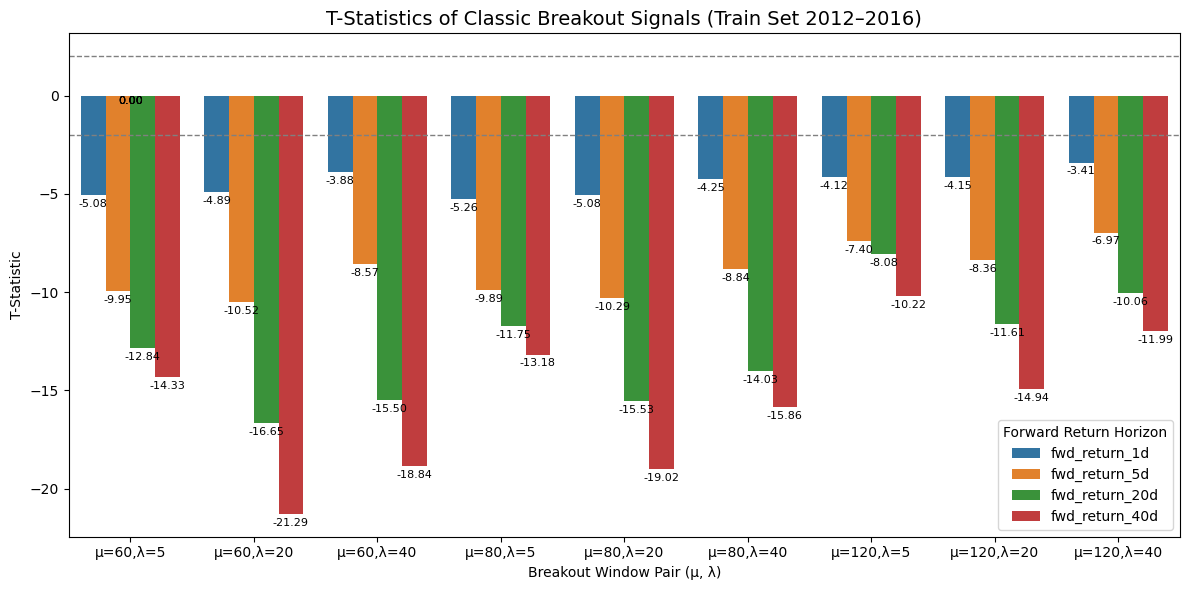

In [26]:
# 1. Breakout signal function
def compute_breakout_signal(px, mu, lam):
    """
    px: np.array of prices
    mu: long window
    lam: short window
    return: np.array of breakout signal (recursive rule)
    """
    b = np.zeros(len(px))
    for t in range(1, len(px)):
        long_window = px[max(0, t - mu + 1): t + 1]
        short_window = px[max(0, t - lam + 1): t + 1]

        if px[t] == np.max(long_window):
            b[t] = 1
        elif px[t] == np.min(long_window):
            b[t] = -1
        elif px[t] == np.max(short_window) or px[t] == np.min(short_window):
            b[t] = 0
        else:
            b[t] = b[t - 1]
    return b

# 2. Define training set
train_df = df[(df['date'] >= '2012-01-01') & (df['date'] <= '2016-12-31')].copy()

# 3. Parameter setup
mu_list = [60, 80, 120]
lam_list = [5, 20, 40]
forward_returns = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d']

# 4. Run breakout signal computation and pooled regression
results = []

for mu in mu_list:
    for lam in lam_list:
        signal_name = f'breakout_mu{mu}_lam{lam}'
        temp_list = []

        for ticker, g in train_df.groupby('ticker'):
            g = g.sort_values('date')
            px = g['PX_LAST'].values
            signal = compute_breakout_signal(px, mu, lam)

            temp = g[['date', 'ticker']].copy()
            temp[signal_name] = signal
            temp_list.append(temp)

        signal_df = pd.concat(temp_list, axis=0)
        merged_df = pd.merge(train_df, signal_df, on=['date', 'ticker'], how='left')

        for target in forward_returns:
            temp = merged_df[[signal_name, target]].dropna()
            if len(temp) < 20:
                continue
            X = sm.add_constant(temp[signal_name])
            y = temp[target]
            model = sm.OLS(y, X).fit()

            results.append({
                'pair': f'μ={mu},λ={lam}',
                'mu': mu,
                'lam': lam,
                'target': target,
                't_value': model.tvalues[signal_name],
                'coef': model.params[signal_name]
            })

# 5. Create result DataFrame
result_df = pd.DataFrame(results)

# 6. Visualization
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=result_df, x='pair', y='t_value', hue='target')

# Annotate each bar
for bar in ax.patches:
    height = bar.get_height()
    if not np.isnan(height):
        x = bar.get_x() + bar.get_width() / 2
        ax.text(x, height + 0.2 * np.sign(height), f"{height:.2f}",
                ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

# Add significance lines
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

plt.title("T-Statistics of Classic Breakout Signals (Train Set 2012–2016)", fontsize=14)
plt.xlabel("Breakout Window Pair (μ, λ)")
plt.ylabel("T-Statistic")
plt.legend(title="Forward Return Horizon")
plt.tight_layout()
plt.show()

In [27]:
# Select best (mu, lam) pair by min/mean |t| ranking

# Compute absolute t-statistics for evaluation
result_df['abs_t'] = result_df['t_value'].abs()

# Aggregate window-level statistics: minimum and mean absolute t-values
rank_df = (
    result_df
    .groupby(['mu', 'lam'])['abs_t']
    .agg(min_abs_t='min', mean_abs_t='mean')
    .reset_index()
)

# Compute dense ranks (ascending) for both min and mean absolute t-values
rank_df['min_rank'] = rank_df['min_abs_t'].rank(method='dense', ascending=True)
rank_df['mean_rank'] = rank_df['mean_abs_t'].rank(method='dense', ascending=True)

# Final ranking score: sum of the two ranks
rank_df['rank_score'] = rank_df['min_rank'] + rank_df['mean_rank']

# Select the (mu, lam) pair with the highest rank_score
# If there are ties, break by choosing the one with the highest mean_abs_t
max_score = rank_df['rank_score'].max()
candidates = rank_df[rank_df['rank_score'] == max_score]
best_row = candidates.loc[candidates['mean_abs_t'].idxmax()]

# Print the best window combination and its statistics
print(f"Best Breakout Window Pair: μ={int(best_row['mu'])}, λ={int(best_row['lam'])}")
print(f"  - Min |t|: {best_row['min_abs_t']:.2f}")
print(f"  - Mean |t|: {best_row['mean_abs_t']:.2f}")
print(f"  - Rank Score: {int(best_row['rank_score'])}")

Best Breakout Window Pair: μ=60, λ=20
  - Min |t|: 4.89
  - Mean |t|: 13.34
  - Rank Score: 15


In [28]:
# Signal parameters
mu, lam = 60, 20
signal_name = f'classic_breakout_{mu}_{lam}'

# Generate breakout signal per ticker
signal_list = []

for ticker, g in df.groupby('ticker'):
    g = g.sort_values('date')
    px = g['PX_LAST'].values
    sig = compute_breakout_signal(px, mu, lam)

    temp = g[['date', 'ticker']].copy()
    temp[signal_name] = -sig
    signal_list.append(temp)

# Merge breakout signals back to main DataFrame
signal_df = pd.concat(signal_list, axis=0)
df = pd.merge(df, signal_df, on=['date', 'ticker'], how='left')

df.head()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,...,fwd_return_20d,fwd_return_40d,daily_rf_return,vrp_std_250,PE_RATIO_signal_60,PX_TO_BOOK_RATIO_signal_60,PX_TO_SALES_RATIO_signal_60,PX_LAST_EWMA_signal_span60,crossover_signal,classic_breakout_60_20
0,2010-01-04,ACN,42.20,41.50,41.50,42.07,1122800.0,16.3173,10.6855,1.1719,...,-0.010740,-0.034078,0.000002,NaN,NaN,NaN,NaN,-0.000000,-0.000000,-0.0
1,2010-01-05,ACN,42.45,41.99,42.09,42.33,755600.0,16.4182,10.7516,1.1791,...,-0.017294,-0.033642,0.000002,NaN,NaN,NaN,NaN,-0.005976,-0.001907,-1.0
2,2010-01-06,ACN,42.90,41.81,42.09,42.78,1361300.0,16.5927,10.8659,1.1916,...,-0.050763,-0.037478,0.000002,NaN,NaN,NaN,NaN,-0.016115,-0.006430,-1.0
3,2010-01-07,ACN,42.89,42.24,42.43,42.74,1402100.0,16.5772,10.8557,1.1905,...,-0.051509,-0.030018,0.000002,NaN,NaN,NaN,NaN,-0.014661,-0.009021,-1.0
4,2010-01-08,ACN,43.06,42.20,42.35,42.57,1363800.0,16.5112,10.8125,1.1858,...,-0.056409,-0.012043,0.000002,NaN,NaN,NaN,NaN,-0.010273,-0.009385,-1.0


## 8. Momentum Signal: Continuous Breakout Signal

This section builds a **continuous breakout signal** that combines long- and short-term breakout conditions, along with a decay factor to keep signal memory over time.  
The predictive strength of this signal is tested through cross-sectional regressions on future returns.

---

### 1. Signal Definition

The signal uses two lookback windows:

- $\mu$: long-term window  
- $\lambda$: short-term window  
- $\delta$: decay factor that keeps part of the previous signal, with $\delta \in (0, 1)$  

The signal $s_t$ at time $t$ is updated as:

$$
s_t = \delta \cdot s_{t-1}
+ \mathbb{1}\left(P_t > \max(P_{t-\mu}, \dots, P_{t-1})\right)
- \mathbb{1}\left(P_t < \min(P_{t-\mu}, \dots, P_{t-1})\right)
+ \mathbb{1}\left(P_t > \max(P_{t-\lambda}, \dots, P_{t-1})\right)
- \mathbb{1}\left(P_t < \min(P_{t-\lambda}, \dots, P_{t-1})\right)
$$

Where $P_t$ is the price at time $t$, and $\mathbb{1}(\cdot)$ is the indicator function.  
The first part reflects breakouts over the long window, the second part checks short-term extremes, and the decay keeps the signal from changing too quickly.

---

### 2. Regression Framework

To test the signal, a series of cross-sectional regressions are run:

$$
r_{i,t+h} = \alpha_t + \beta_t \cdot s_{i,t} + \varepsilon_{i,t}
$$

Where:

- $r_{i,t+h}$: return over horizon $h$ for stock $i$  
- $s_{i,t}$: breakout signal for stock $i$  
- $\beta_t$: slope of the regression  
- The **t-statistic** of $\beta_t$ shows how strong the signal is

---

### 3. Parameter Grid

The signal is tested over many settings:

- $\mu \in \{60, 80, 120\}$  
- $\lambda \in \{5, 20, 40\}$  
- $\delta \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$  

Forward return targets:

- 1-day return  
- 5-day return  
- 20-day return  
- 40-day return

---

### 4. Signal Selection Criteria

For each setting $(\mu, \lambda, \delta)$, two metrics are calculated:

- Minimum $|t|$: weakest performance across horizons  
- Mean $|t|$: average strength across all horizons  

The total score is:

$$
\text{Score} = \text{Rank}_{\min |t|} + \text{Rank}_{\text{mean} |t|}
$$

The best signal is the one with the highest score — strong on average and never too weak.

---

### 5. Visualization

Bar charts are created to show $t$-statistics for each setting.  
Each chart is grouped by decay level, with bars for different $(\mu, \lambda)$ combinations and return horizons.  
Dashed lines at $t = \pm 2$ mark the common cutoff for statistical significance.

## Chart Analysis

T-statistics from pooled cross-sectional regressions show consistently negative values across all parameter settings,  
confirming a strong mean-reversion effect after large breakout moves.

Signal strength becomes stronger with longer return horizons and higher decay levels.  
Clear and stable t-statistics are observed when decay is **0.5 or higher**, especially for 20-day and 40-day returns.

Best-performing configuration:

- Long window ($\mu$): 60 days  
- Short window ($\lambda$): 5 days  
- Decay: 0.9  
- **Minimum $|t|$**: 7.18  
- **Mean $|t|$**: 13.21  
- **Rank Score**: 83

---

### Final Signal Configuration

- Signal type: continuous breakout  
- Long window: 60 days  
- Short window: 5 days  
- Decay: 0.9  
- Signal direction: negative

Best Continuous Breakout (global): μ=60, λ=5, decay=0.9
  - Min |t|: 7.18
  - Mean |t|: 13.21
  - Rank Score: 83


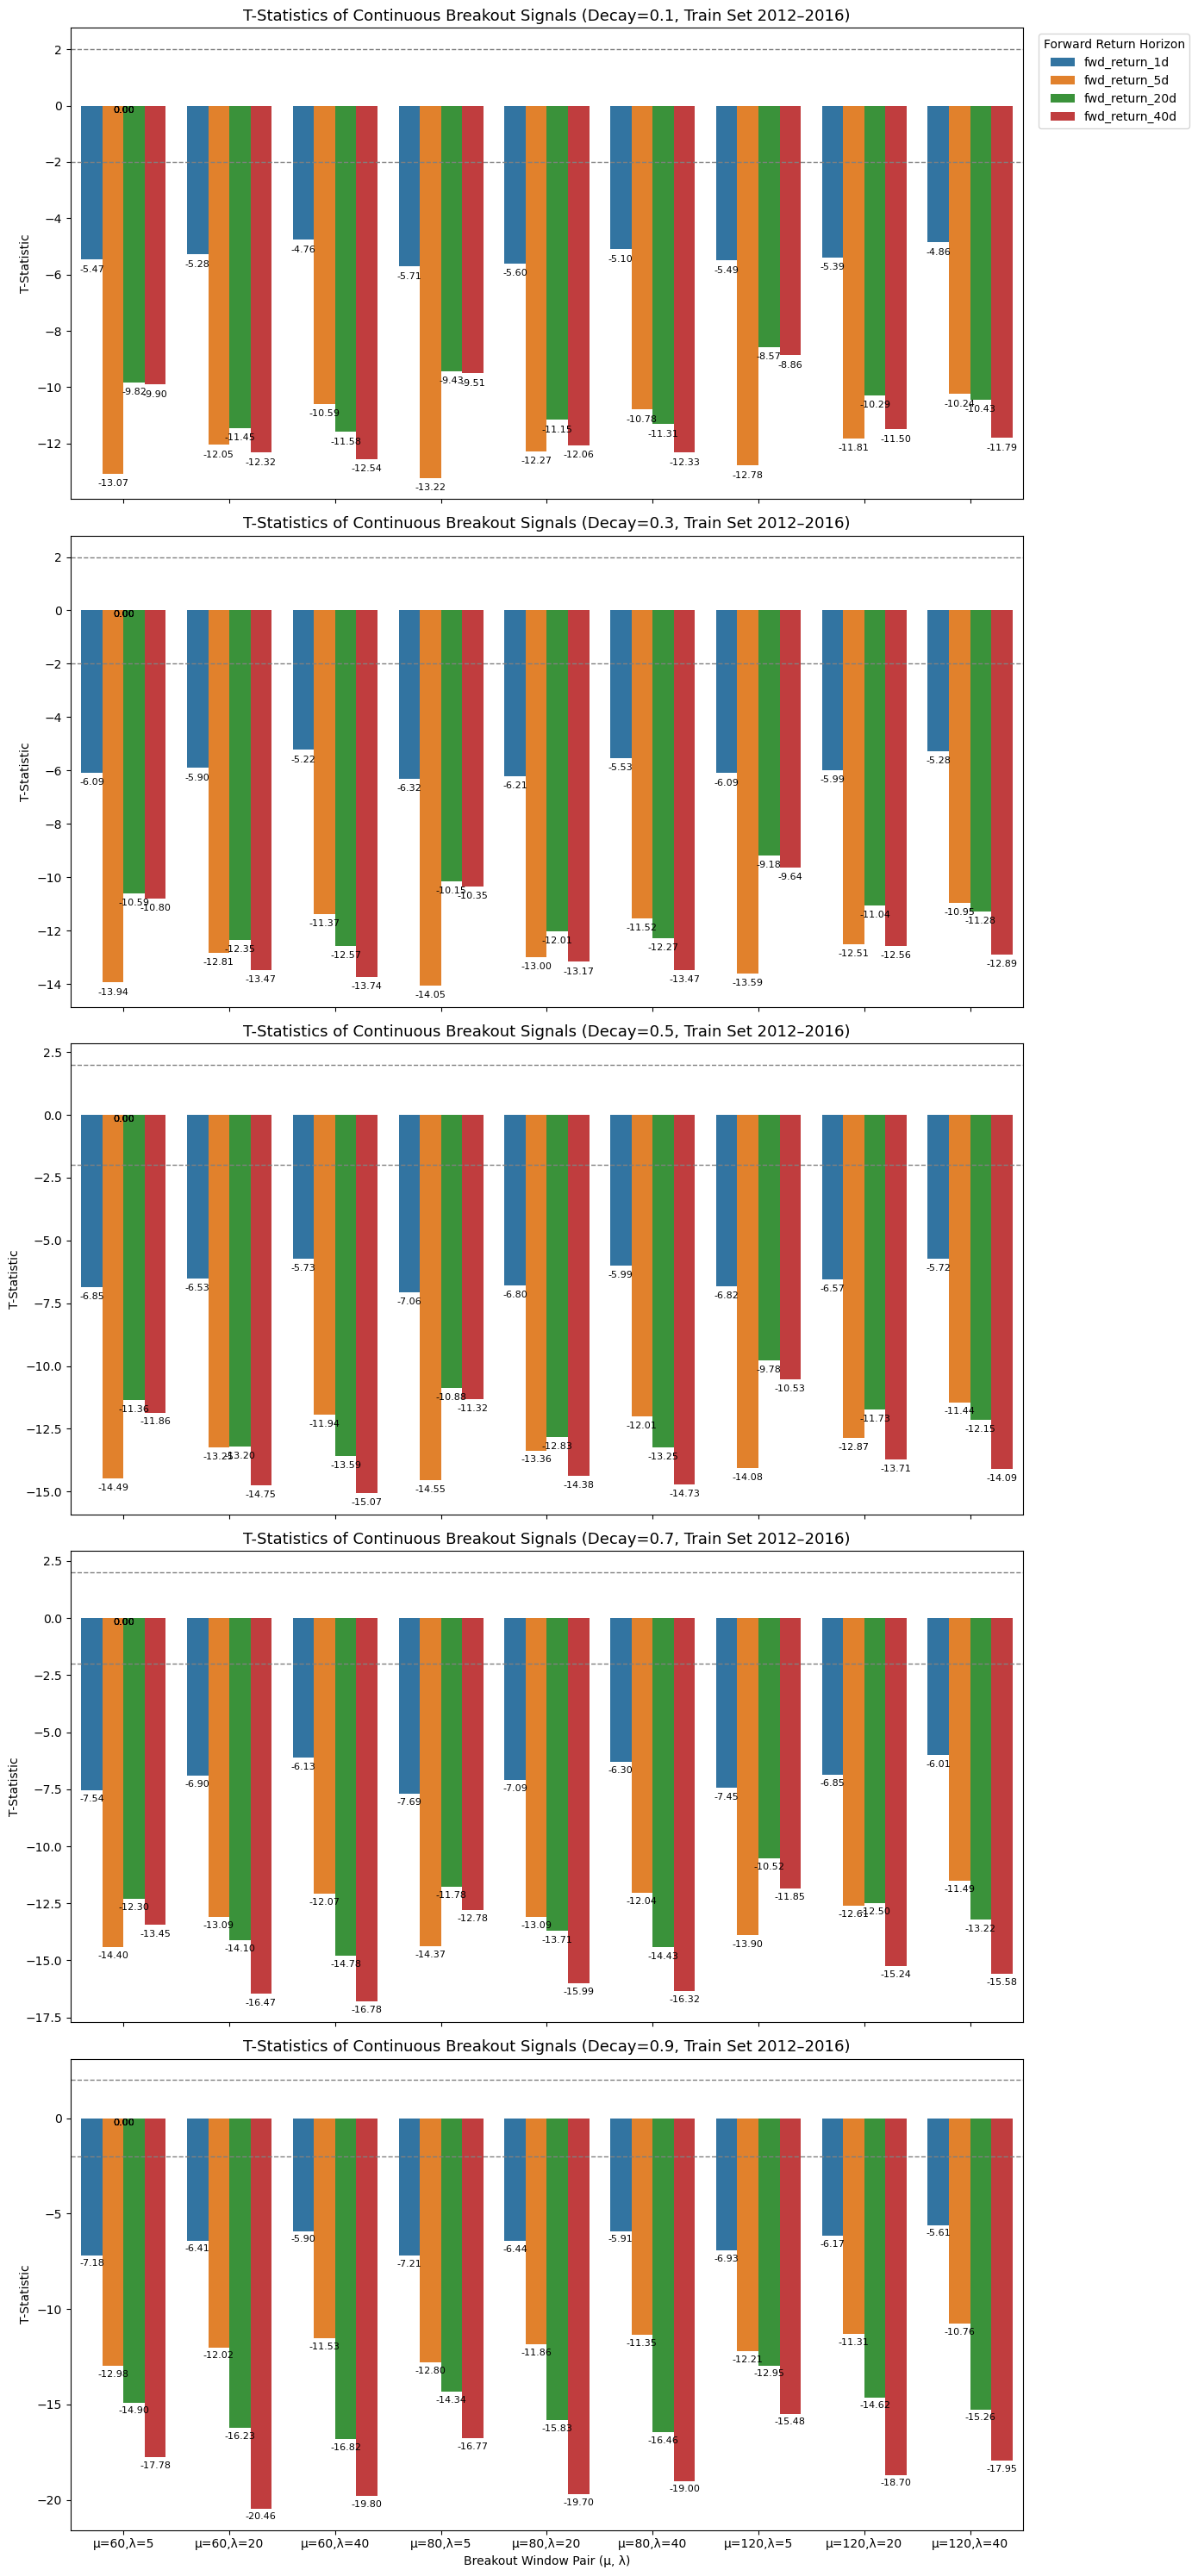

In [29]:
# Continuous Breakout Signal Function
def compute_continuous_breakout(px, mu, lam, decay):
    signal = []
    prev = 0.0
    for t in range(len(px)):
        sig = prev * decay  # Apply decay to previous signal

        if t >= mu:
            long_window = px[t - mu:t]
            if px[t] > np.max(long_window):
                sig += 1
            elif px[t] < np.min(long_window):
                sig -= 1

        if t >= lam:
            short_window = px[t - lam:t]
            if px[t] > np.max(short_window):
                sig += 1
            elif px[t] < np.min(short_window):
                sig -= 1

        signal.append(sig)
        prev = sig
    return np.array(signal)

# Parameter grid
mu_list = [60, 80, 120]                # Long-term breakout windows
lam_list = [5, 20, 40]                 # Short-term breakout windows
decay_list = [0.1, 0.3, 0.5, 0.7, 0.9] # Decay values
forward_returns = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d']

# Define training sample
train_df = df[(df['date'] >= '2012-01-01') & (df['date'] <= '2016-12-31')].copy()

# Collect regression results for all (mu, lam, decay)
results_all = []

for decay in decay_list:
    for mu in mu_list:
        for lam in lam_list:
            sig_name = f'cont_breakout_mu{mu}_lam{lam}_d{decay}'
            temp_list = []

            # Compute signal per ticker
            for ticker, g in train_df.groupby('ticker'):
                g = g.sort_values('date')
                px = g['PX_LAST'].values
                sig = compute_continuous_breakout(px, mu, lam, decay=decay)

                temp = g[['date', 'ticker']].copy()
                temp[sig_name] = sig
                temp_list.append(temp)

            sig_df = pd.concat(temp_list, axis=0)
            merged_df = pd.merge(train_df, sig_df, on=['date', 'ticker'], how='left')

            # Cross-sectional regressions for each return horizon
            for target in forward_returns:
                temp = merged_df[[sig_name, target]].dropna()
                if len(temp) < 20:
                    continue
                X = sm.add_constant(temp[sig_name])
                y = temp[target]
                model = sm.OLS(y, X).fit()

                results_all.append({
                    'decay': decay,
                    'mu': mu,
                    'lam': lam,
                    'pair': f'μ={mu},λ={lam}',
                    'target': target,
                    't_value': model.tvalues[sig_name],
                    'coef': model.params[sig_name]
                })

# Global best parameter selection
result_all_df = pd.DataFrame(results_all)

if not result_all_df.empty:
    result_all_df['abs_t'] = result_all_df['t_value'].abs()

    rank_df = (
        result_all_df
        .groupby(['mu', 'lam', 'decay'])['abs_t']
        .agg(min_abs_t='min', mean_abs_t='mean')
        .reset_index()
    )

    # Dense ranking, sum min/mean ranks
    rank_df['min_rank'] = rank_df['min_abs_t'].rank(method='dense', ascending=True)
    rank_df['mean_rank'] = rank_df['mean_abs_t'].rank(method='dense', ascending=True)
    rank_df['rank_score'] = rank_df['min_rank'] + rank_df['mean_rank']

    # Select best configuration
    max_score = rank_df['rank_score'].max()
    candidates = rank_df[rank_df['rank_score'] == max_score]
    best_row = candidates.loc[candidates['mean_abs_t'].idxmax()]

    print(f"Best Continuous Breakout (global): μ={int(best_row['mu'])}, λ={int(best_row['lam'])}, decay={best_row['decay']}")
    print(f"  - Min |t|: {best_row['min_abs_t']:.2f}")
    print(f"  - Mean |t|: {best_row['mean_abs_t']:.2f}")
    print(f"  - Rank Score: {int(best_row['rank_score'])}")

# Visualization: Facet by decay
fig, axes = plt.subplots(len(decay_list), 1, figsize=(14, 6 * len(decay_list)), sharex=True)

for i, decay in enumerate(decay_list):
    df_dec = result_all_df[result_all_df['decay'] == decay].copy()
    ax = axes[i]
    sns.barplot(data=df_dec, x='pair', y='t_value', hue='target', ax=ax)

    # Annotate t-values
    for bar in ax.patches:
        height = bar.get_height()
        if not np.isnan(height):
            x = bar.get_x() + bar.get_width() / 2
            ax.text(x, height + 0.2 * np.sign(height), f"{height:.2f}",
                    ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

    # Add significance lines
    ax.axhline(2, color='gray', linestyle='--', linewidth=1)
    ax.axhline(-2, color='gray', linestyle='--', linewidth=1)

    ax.set_title(f"T-Statistics of Continuous Breakout Signals (Decay={decay}, Train Set 2012–2016)", fontsize=13)
    ax.set_ylabel("T-Statistic")

    if i == len(decay_list) - 1:
        ax.set_xlabel("Breakout Window Pair (μ, λ)")
    else:
        ax.set_xlabel("")

    if i == 0:
        ax.legend(title="Forward Return Horizon", bbox_to_anchor=(1.01, 1), loc='upper left')
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig("continuous_breakout_tstats.png", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# Construct best continuous breakout signal on full dataset

# Best parameters from global selection
best_mu = 60
best_lam = 5
best_decay = 0.9
signal_col = f'cont_breakout_mu{best_mu}_lam{best_lam}_d{best_decay}'

# Initialize a container for all tickers
signal_list = []

# Compute signal for entire dataset
for ticker, g in df.groupby('ticker'):
    g = g.sort_values('date')
    px = g['PX_LAST'].values
    sig = compute_continuous_breakout(px, mu=best_mu, lam=best_lam, decay=best_decay)

    temp = g[['date', 'ticker']].copy()
    temp[signal_col] = -sig
    signal_list.append(temp)

# Concatenate and merge with full df
signal_df = pd.concat(signal_list, axis=0)
df = pd.merge(df, signal_df, on=['date', 'ticker'], how='left')

In [31]:
df.head()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,...,fwd_return_40d,daily_rf_return,vrp_std_250,PE_RATIO_signal_60,PX_TO_BOOK_RATIO_signal_60,PX_TO_SALES_RATIO_signal_60,PX_LAST_EWMA_signal_span60,crossover_signal,classic_breakout_60_20,cont_breakout_mu60_lam5_d0.9
0,2010-01-04,ACN,42.20,41.50,41.50,42.07,1122800.0,16.3173,10.6855,1.1719,...,-0.034078,0.000002,NaN,NaN,NaN,NaN,-0.000000,-0.000000,-0.0,-0.0
1,2010-01-05,ACN,42.45,41.99,42.09,42.33,755600.0,16.4182,10.7516,1.1791,...,-0.033642,0.000002,NaN,NaN,NaN,NaN,-0.005976,-0.001907,-1.0,-0.0
2,2010-01-06,ACN,42.90,41.81,42.09,42.78,1361300.0,16.5927,10.8659,1.1916,...,-0.037478,0.000002,NaN,NaN,NaN,NaN,-0.016115,-0.006430,-1.0,-0.0
3,2010-01-07,ACN,42.89,42.24,42.43,42.74,1402100.0,16.5772,10.8557,1.1905,...,-0.030018,0.000002,NaN,NaN,NaN,NaN,-0.014661,-0.009021,-1.0,-0.0
4,2010-01-08,ACN,43.06,42.20,42.35,42.57,1363800.0,16.5112,10.8125,1.1858,...,-0.012043,0.000002,NaN,NaN,NaN,NaN,-0.010273,-0.009385,-1.0,-0.0


## 9. Mean-Reverting Momentum Signal: RSI Signal

This section evaluates the predictive power of RSI-based signals using cross-sectional regressions over the 2012–2016 training period.

---

### 1. RSI Construction

The **Relative Strength Index (RSI)** is a momentum signal that compares recent price gains to recent losses over a window of $w$ days:

$$
\text{RSI}_t = 100 - \frac{100}{1 + RS_t}
$$

Where:

- $RS_t = \frac{\text{Average Gain}_t}{\text{Average Loss}_t}$  
- Average Gain and Loss are calculated over the past $w$ days

RSI values range from 0 to 100:

- RSI > 70 → possible overbought  
- RSI < 30 → possible oversold  
- RSI ≈ 50 → neutral

---

### 2. Signal Normalization

To make the RSI easier to use in regression, it is rescaled to range from -1 to 1:

$$
\text{Signal}_t = \frac{\text{RSI}_t - 50}{50}
$$

- Signal = +1 → strong upward momentum  
- Signal = -1 → strong downward momentum  
- Signal = 0 → neutral

---

### 3. Regression Framework

The signal is tested using pooled cross-sectional OLS regressions:

$$
r_{i,t+h} = \alpha + \beta \cdot \text{RSI}_{i,t}^{(w)} + \varepsilon_{i,t}
$$

Where:

- $r_{i,t+h}$: forward return over $h$ days  
- $\text{RSI}_{i,t}^{(w)}$: normalized RSI signal with lookback $w$  
- $\beta$: signal strength  

The **t-statistic** of $\beta$ shows how meaningful the signal is.

---

### 4. Parameter Grid

RSI signals are tested with the following lookback windows:

- $w \in \{5, 20, 60, 120, 250\}$

Return horizons tested:

- $h \in \{1, 5, 20, 40\}$ (days)

---

### 5. Visualization: T-Statistics of RSI Signals

Bar charts show the t-statistics for each $(w, h)$ pair.  
Dashed lines at $t = \pm 2$ mark common significance levels.

- Positive t-values → trend-following (momentum)  
- Negative t-values → reversal (mean reversion)

---

## Chart Analysis

The chart below shows $t$-statistics from pooled cross-sectional regressions of normalized RSI signals on forward returns.  
Each bar corresponds to a different RSI lookback window and return horizon.

---

### Best Performing RSI Window: 60 days

- **Minimum $|t|$**: 6.31  
- **Mean $|t|$**: 16.72  
- **Rank Score**: 9

---

### Signal Interpretation

- All $t$-values are negative across all windows and horizons, indicating **mean reversion**.
- The **60-day RSI** shows the strongest and most consistent negative effect:

  - 1-day forward return: $t = -6.31$  
  - 5-day forward return: $t = -14.09$  
  - 20-day forward return: $t = -21.82$  
  - 40-day forward return: $t = -24.67$

- Predictive strength increases with longer holding periods.
- Shorter windows (5, 20) and longer ones (120, 250) perform worse than 60-day.

---

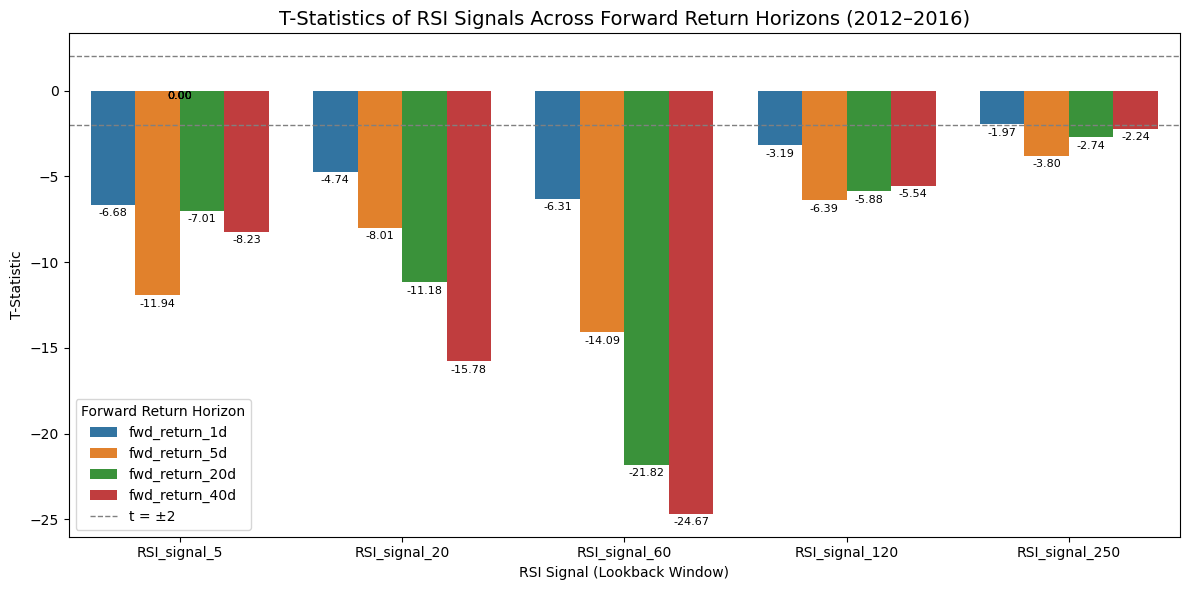

In [32]:
# Function: Compute RSI
def compute_rsi(prices, window):
    """
    Compute Relative Strength Index (RSI) over a given window.

    Parameters:
        prices (np.array): 1D array of prices
        window (int): Lookback period for RSI calculation

    Returns:
        np.array: RSI values (NaN for the first `window` values)
    """
    deltas = np.diff(prices, prepend=prices[0])
    gains = np.where(deltas > 0, deltas, 0)
    losses = np.where(deltas < 0, -deltas, 0)

    avg_gain = pd.Series(gains).rolling(window=window, min_periods=window).mean()
    avg_loss = pd.Series(losses).rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi.values

# RSI configuration
rsi_windows = [5, 20, 60, 120, 250]
signal_dfs = []

# Compute RSI signals for each ticker and window
for window in rsi_windows:
    signal_list = []

    for ticker, g in df.groupby('ticker'):
        g = g.sort_values('date')
        px = g['PX_LAST'].values
        rsi = compute_rsi(px, window)

        # Normalize RSI to range [-1, 1], where 0 = neutral (RSI = 50)
        signal = (rsi - 50) / 50

        temp = g[['date', 'ticker']].copy()
        temp[f'RSI_signal_{window}'] = signal
        signal_list.append(temp)

    signal_df = pd.concat(signal_list, axis=0)
    signal_dfs.append(signal_df)

# Merge all RSI signals into one DataFrame
rsi_all_signals = signal_dfs[0].copy()
for i in range(1, len(signal_dfs)):
    rsi_all_signals = pd.merge(
        rsi_all_signals,
        signal_dfs[i],
        on=['date', 'ticker'],
        how='outer'
    )

# Define in-sample training period
train_df = df[(df['date'] >= '2012-01-01') & (df['date'] <= '2016-12-31')].copy()

# Merge RSI signals into main DataFrame
train_df = pd.merge(train_df, rsi_all_signals, on=['date', 'ticker'], how='left')

# Define forward return targets
forward_returns = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d']
results = []

# Run cross-sectional OLS regressions
for signal_col in [f'RSI_signal_{w}' for w in rsi_windows]:
    for target in forward_returns:
        temp = train_df[[signal_col, target]].dropna()
        if len(temp) < 50:
            continue

        X = sm.add_constant(temp[signal_col])
        y = temp[target]
        model = sm.OLS(y, X).fit()

        results.append({
            'signal': signal_col,
            'target': target,
            't_value': model.tvalues[signal_col],
            'coef': model.params[signal_col]
        })

# Convert results to DataFrame
result_df = pd.DataFrame(results)

# Visualization: T-statistics of RSI signals
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=result_df, x='signal', y='t_value', hue='target')

# Annotate t-values above each bar
for bar in ax.patches:
    height = bar.get_height()
    if not np.isnan(height):
        x = bar.get_x() + bar.get_width() / 2
        ax.text(x, height + 0.2 * np.sign(height), f"{height:.2f}",
                ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

# Add significance threshold lines
plt.axhline(2, color='gray', linestyle='--', linewidth=1, label='t = ±2')
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

plt.title("T-Statistics of RSI Signals Across Forward Return Horizons (2012–2016)", fontsize=14)
plt.xlabel("RSI Signal (Lookback Window)")
plt.ylabel("T-Statistic")
plt.legend(title="Forward Return Horizon")
plt.tight_layout()
plt.show()

In [33]:
# Select the optimal RSI window based on min/mean |t|
if not result_df.empty:
    result_df['abs_t'] = result_df['t_value'].abs()

    # Extract RSI window size from signal name
    result_df['window'] = result_df['signal'].str.extract(r'RSI_signal_(\d+)').astype(int)

    # Group by window and compute min and mean absolute t-statistics
    rank_df = (
        result_df
        .groupby('window')['abs_t']
        .agg(min_abs_t='min', mean_abs_t='mean')
        .reset_index()
    )

    # Apply dense ranking (ascending); lower t-value → lower rank; higher total rank_score is better
    rank_df['min_rank'] = rank_df['min_abs_t'].rank(method='dense', ascending=True)
    rank_df['mean_rank'] = rank_df['mean_abs_t'].rank(method='dense', ascending=True)
    rank_df['rank_score'] = rank_df['min_rank'] + rank_df['mean_rank']

    # Select best window: highest rank_score, tie-break by highest mean_abs_t
    max_score = rank_df['rank_score'].max()
    candidates = rank_df[rank_df['rank_score'] == max_score]
    best_row = candidates.loc[candidates['mean_abs_t'].idxmax()]

    # Output the best-performing RSI window and stats
    print(f"Best RSI Window: {int(best_row['window'])} days")
    print(f"  - Min |t|: {best_row['min_abs_t']:.2f}")
    print(f"  - Mean |t|: {best_row['mean_abs_t']:.2f}")
    print(f"  - Rank Score: {int(best_row['rank_score'])}")

Best RSI Window: 60 days
  - Min |t|: 6.31
  - Mean |t|: 16.72
  - Rank Score: 9


In [34]:
df = pd.merge(df, rsi_all_signals[['date', 'ticker', 'RSI_signal_60']], on=['date', 'ticker'], how='left')
df['RSI_signal_60'] = -df['RSI_signal_60']
df.head()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,...,daily_rf_return,vrp_std_250,PE_RATIO_signal_60,PX_TO_BOOK_RATIO_signal_60,PX_TO_SALES_RATIO_signal_60,PX_LAST_EWMA_signal_span60,crossover_signal,classic_breakout_60_20,cont_breakout_mu60_lam5_d0.9,RSI_signal_60
0,2010-01-04,ACN,42.20,41.50,41.50,42.07,1122800.0,16.3173,10.6855,1.1719,...,0.000002,NaN,NaN,NaN,NaN,-0.000000,-0.000000,-0.0,-0.0,NaN
1,2010-01-05,ACN,42.45,41.99,42.09,42.33,755600.0,16.4182,10.7516,1.1791,...,0.000002,NaN,NaN,NaN,NaN,-0.005976,-0.001907,-1.0,-0.0,NaN
2,2010-01-06,ACN,42.90,41.81,42.09,42.78,1361300.0,16.5927,10.8659,1.1916,...,0.000002,NaN,NaN,NaN,NaN,-0.016115,-0.006430,-1.0,-0.0,NaN
3,2010-01-07,ACN,42.89,42.24,42.43,42.74,1402100.0,16.5772,10.8557,1.1905,...,0.000002,NaN,NaN,NaN,NaN,-0.014661,-0.009021,-1.0,-0.0,NaN
4,2010-01-08,ACN,43.06,42.20,42.35,42.57,1363800.0,16.5112,10.8125,1.1858,...,0.000002,NaN,NaN,NaN,NaN,-0.010273,-0.009385,-1.0,-0.0,NaN


## 10. HOP(Hurst, Oui, and Pederson) Momentum Signal Construction

It captures trends in **volatility-adjusted excess returns** using rolling windows.  
The construction process includes excess return calculation, volatility adjustment, signal smoothing, and regression-based evaluation.

---

### Step 1: Compute Daily Excess Log Return

- **Log return**:

  $$
  r_{t}^{\text{log}} = \ln\left(\frac{P_t}{P_{t-1}}\right)
  $$

- **Log risk-free return**:

  $$
  r_{t}^{\text{rf}} = \ln(1 + \text{RF}_t)
  $$

- **Excess return**:

  $$
  r_t^{\text{excess}} = r_t^{\text{log}} - r_t^{\text{rf}}
  $$

---

### Step 2: Estimate Volatility (ATR-based EWMA)

- **True range**:

  $$
  \text{TR}_t = \max\left( 
    \text{High}_t - \text{Low}_t,\ 
    |\text{High}_t - P_{t-1}|,\ 
    |\text{Low}_t - P_{t-1}|
  \right)
  $$

- **EWMA volatility estimate**:

  $$
  \sigma_t = \text{EWMA}_{20}(\text{TR}_t)
  $$

---

### Step 3: Compute Standardized Excess Return

- **Standardized signal**:

  $$
  s_t = \frac{r_t^{\text{excess}}}{\sigma_t}
  $$

This creates a return signal adjusted for recent volatility.

---

### Step 4: Build Rolling Momentum Signals

For each window $w \in \{20, 40, 60, ..., 240\}$:

$$
\text{Momentum}_{t}^{(w)} = \sum_{i=0}^{w-1} s_{t-i}
$$

This generates multiple signals like:

- `momentum_20d`, `momentum_40d`, ..., `momentum_240d`

Each captures cumulative standardized return over different periods.

---

### Step 5: Evaluate via Cross-Sectional Regression

Each signal is tested using daily cross-sectional regressions:

$$
r_{i,t+h} = \alpha_t + \beta_t \cdot \text{Momentum}_{i,t}^{(w)} + \varepsilon_{i,t}
$$

Where:

- $r_{i,t+h}$ is the forward return over $h \in \{1, 5, 20, 40\}$  
- $\beta_t$ measures how well the signal predicts returns  
- The **t-statistic** of $\beta_t$ is used to judge performance

---

For each return horizon, the **top two windows** with the highest absolute $t$-statistics are selected as the final HOP momentum features.

## HOP Momentum Signal Selection Procedure

### Step 1: Top-2 Signal Selection per Target

For each forward return horizon (1-day, 5-day, 20-day, 40-day),  
the two momentum signals with the **highest absolute t-statistics** are selected.  
This ensures the strongest signals are chosen, regardless of whether they predict up or down moves.

---

### Step 2: Construct Unique Signal Set

From the selected signals, keep only the **unique momentum windows**, preserving the order in which they were chosen.  
This results in a final set of HOP momentum features to be used in the model.

Final selected signals:

- `momentum_60d`: 60-day cumulative standardized excess return  
- `momentum_20d`: 20-day cumulative standardized excess return  
- `momentum_200d`: 200-day cumulative standardized excess return  
- `momentum_220d`: 220-day cumulative standardized excess return  
- `momentum_80d`: 80-day cumulative standardized excess return  

## Chart Analysis

$t$-statistics from cross-sectional regressions of HOP momentum signals vs. forward returns, evaluated at various momentum windows:

---

### fwd_return_1d

- Significant reversal in 20–60d windows:
  - 60d: $t = -2.51$
  - 20d: $t = -1.95$
- Weakly positive but insignificant $t$ after 80d:
  - 120d–240d: $t$ between 0.3 and 0.5

---

### fwd_return_5d

- Clear mean-reversion in 20–80d windows:
  - 60d: $t = -5.43$
  - 80d: $t = -3$
- Modest positive $t$ for windows >100d, but none exceeds significance ($t < 2$)

---

### fwd_return_20d

- Momentum emerges for 100d+ windows:
  - 200d: $t = 5.37$
  - 240d: $t = 5.60$

---

### fwd_return_40d

- Strongest signal in 160d–220d range:
  - 200d: $t = 9.34$
  - 220d: $t = 9.50$

---

In [35]:
# Sort by ticker and date to ensure correct time series order
df_mom = df.sort_values(['ticker', 'date']).copy()

# Compute log return and excess return
df_mom['log_return'] = df_mom.groupby('ticker')['PX_LAST'].transform(lambda x: np.log(x / x.shift(1)))
df_mom['log_rf'] = np.log(1 + df_mom['daily_rf_return']) 
df_mom['excess_return'] = df_mom['log_return'] - df_mom['log_rf']

# Compute True Range (max of High-Low and High/Low - PrevClose)
df_mom['prev_close'] = df_mom.groupby('ticker')['PX_LAST'].shift(1)
df_mom['tr'] = df_mom[['PX_HIGH', 'PX_LOW', 'prev_close']].apply(
    lambda row: max(
        row['PX_HIGH'] - row['PX_LOW'],
        abs(row['PX_HIGH'] - row['prev_close']),
        abs(row['PX_LOW'] - row['prev_close'])
    ), axis=1
)

# 20-day EWMA volatility estimate using ATR proxy
df_mom['vol_ewma_20d'] = df_mom.groupby('ticker')['tr'].transform(lambda x: x.ewm(span=20).mean())

# Standardized daily excess return (vol-adjusted signal)
df_mom['daily_signal'] = df_mom['excess_return'] / df_mom['vol_ewma_20d']

# Construct multi-window HOP momentum signals as rolling sum of standardized signals
momentum_windows = list(range(20, 241, 20))  # [20, 40, ..., 240]
for window in momentum_windows:
    df_mom[f'momentum_{window}d'] = df_mom.groupby('ticker')['daily_signal'].transform(lambda x: x.rolling(window).sum())

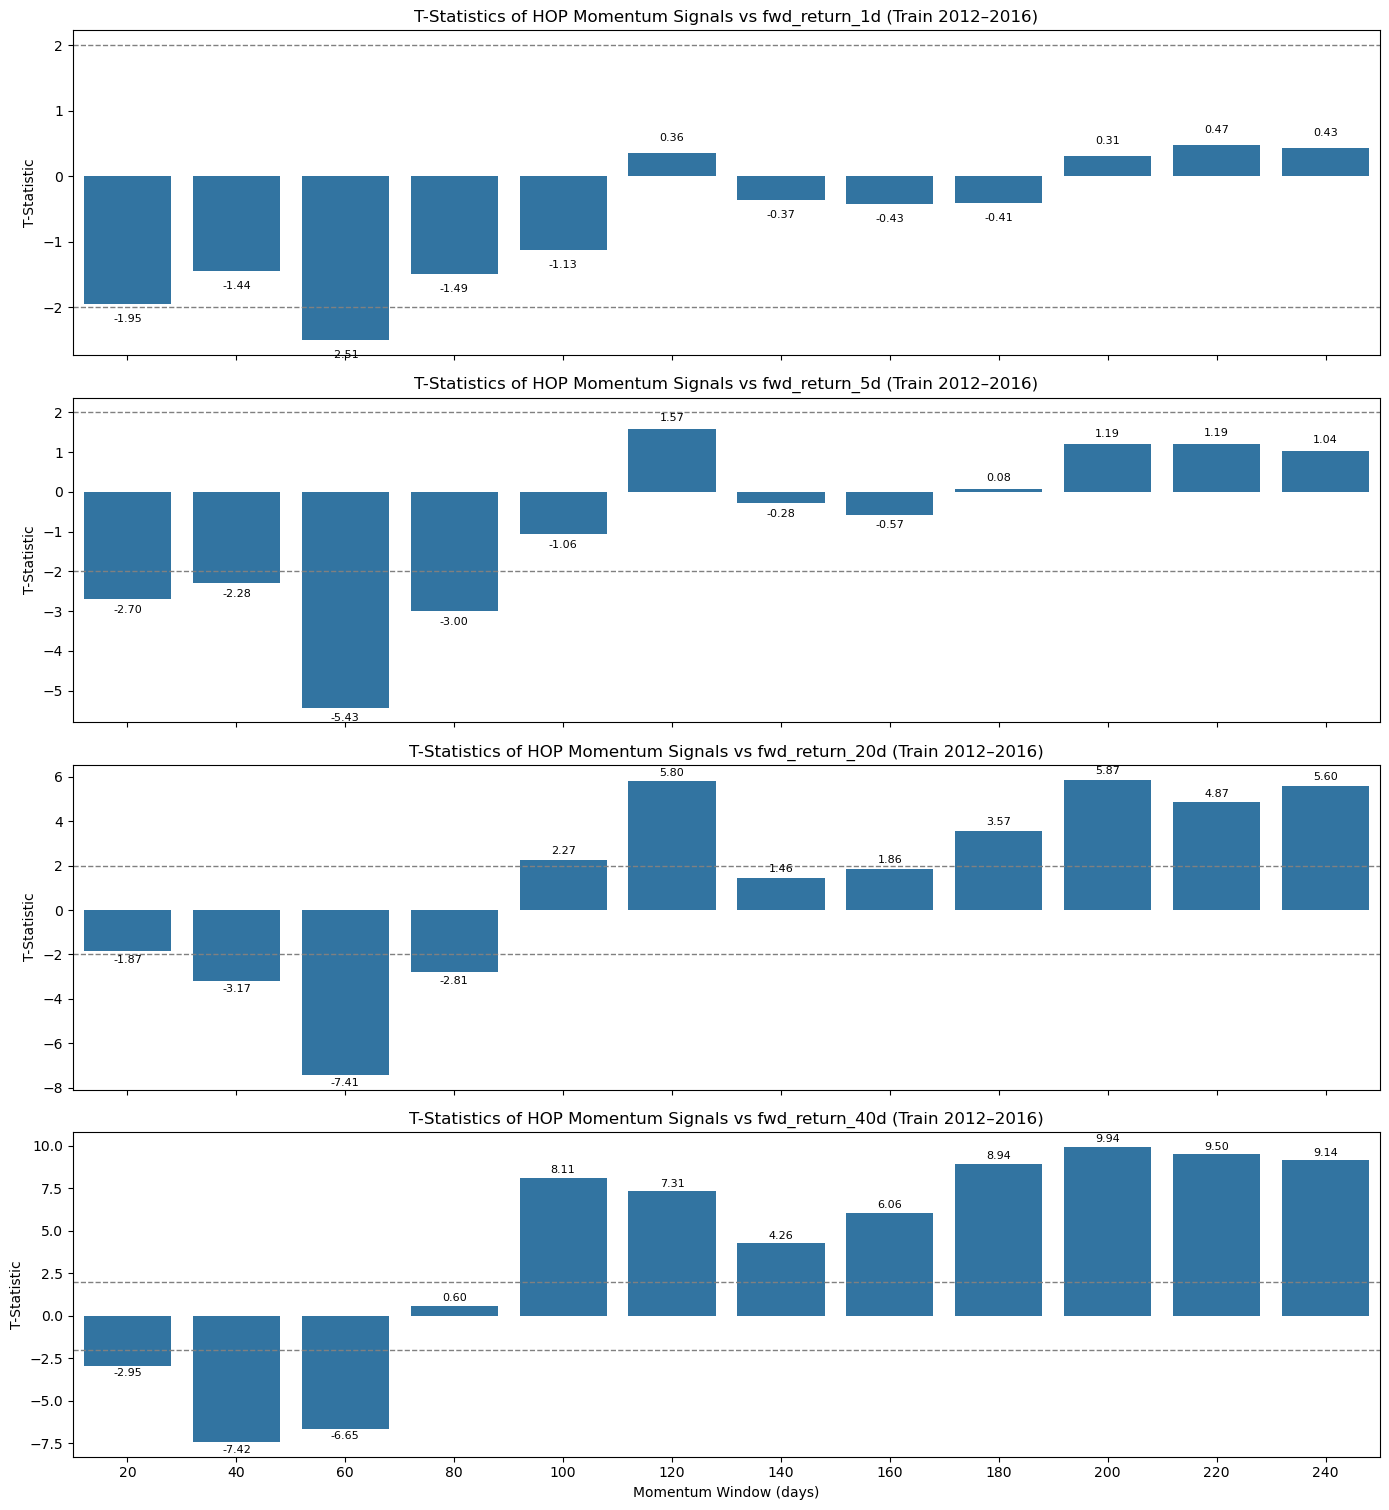

In [36]:
# Define in-sample training period
train_df = df_mom[(df_mom['date'] >= '2012-01-01') & (df_mom['date'] <= '2016-12-31')].copy()

# Evaluate predictive power: momentum_{window}d vs forward returns
forward_returns = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d']
results = []

for window in momentum_windows:
    signal_col = f'momentum_{window}d'
    if signal_col not in train_df.columns:
        continue
    for ret_col in forward_returns:
        temp = train_df[[signal_col, ret_col]].dropna()
        if len(temp) < 50:
            continue
        X = sm.add_constant(temp[signal_col])
        y = temp[ret_col]
        try:
            model = sm.OLS(y, X).fit()
            results.append({
                'window': window,
                'target': ret_col,
                't_value': float(model.tvalues[signal_col]),
                'coef': float(model.params[signal_col]),
                'n_obs': int(len(temp))
            })
        except Exception:
            continue

result_df = pd.DataFrame(results)

# Visualization: one forward return per subplot
if not result_df.empty:
    ordered_windows = sorted(set(result_df['window']))
    nrows = len(forward_returns)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(14, 3.8 * nrows), sharex=True)

    if nrows == 1:
        axes = [axes]

    for i, ret_col in enumerate(forward_returns):
        ax = axes[i]
        df_sub = result_df[result_df['target'] == ret_col].copy()

        # Barplot of t-values by momentum window
        sns.barplot(
            data=df_sub,
            x='window',
            y='t_value',
            order=ordered_windows,
            ax=ax
        )

        # Annotate each bar with t-stat value
        for bar in ax.patches:
            height = bar.get_height()
            if not np.isnan(height):
                x = bar.get_x() + bar.get_width() / 2
                ax.text(
                    x,
                    height + 0.15 * np.sign(height),
                    f"{height:.2f}",
                    ha='center',
                    va='bottom' if height > 0 else 'top',
                    fontsize=8
                )

        # Reference lines for significance
        ax.axhline(2, color='gray', linestyle='--', linewidth=1)
        ax.axhline(-2, color='gray', linestyle='--', linewidth=1)

        ax.set_title(f"T-Statistics of HOP Momentum Signals vs {ret_col} (Train 2012–2016)")
        ax.set_ylabel("T-Statistic")

        # Only bottom subplot shows the shared x-label
        if i == nrows - 1:
            ax.set_xlabel("Momentum Window (days)")
        else:
            ax.set_xlabel("")

    plt.tight_layout()
    plt.show()
else:
    print("No valid regression results to plot. Check data availability and thresholds.")

In [37]:
# Step 1: Select top-2 most significant momentum windows (by |t-stat|) for each forward return horizon
hop_signal_selection = (
    result_df.assign(abs_t=result_df['t_value'].abs())
    .sort_values(['target', 'abs_t'], ascending=[True, False])
    .groupby('target')
    .head(2)
)

# Step 2: Extract selected signal names (unique, ordered by importance)
selected_signals = list(OrderedDict.fromkeys(
    f"momentum_{int(row['window'])}d" for _, row in hop_signal_selection.iterrows()
))
selected_signals

['momentum_60d',
 'momentum_20d',
 'momentum_200d',
 'momentum_220d',
 'momentum_80d']

In [38]:
# Prepare signal dataframe with only date, ticker, and selected signals
df_signals = df_mom[['date', 'ticker'] + selected_signals].copy()

# Merge selected HOP momentum signals back into the original df
# This ensures all rows in df are preserved (left join), and signal values are aligned by ticker & date
df = df.merge(df_signals, on=['date', 'ticker'], how='left')

In [39]:
df.tail()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,...,PX_LAST_EWMA_signal_span60,crossover_signal,classic_breakout_60_20,cont_breakout_mu60_lam5_d0.9,RSI_signal_60,momentum_60d,momentum_20d,momentum_200d,momentum_220d,momentum_80d
127369,2020-12-24,WFC,30.350,29.665,30.35,29.84,2961029.0,46.6354,0.7704,1.4291,...,-0.116802,-0.122974,-1.0,-3.523231,-0.209811,0.232908,0.038563,0.124516,-0.221841,0.212474
127370,2020-12-28,WFC,30.475,29.910,30.05,29.93,4327450.0,46.7761,0.7727,1.4334,...,-0.115775,-0.122435,-1.0,-3.170908,-0.210857,0.233677,0.046950,0.080378,-0.227536,0.185174
127371,2020-12-29,WFC,30.165,29.750,30.10,29.78,4343416.0,46.5416,0.7688,1.4262,...,-0.106186,-0.119230,-1.0,-2.853817,-0.193451,0.205303,0.082430,0.127999,-0.236376,0.181898
127372,2020-12-30,WFC,30.040,29.655,29.80,29.75,4007378.0,46.4948,0.7680,1.4248,...,-0.101278,-0.115719,-1.0,-2.568436,-0.179661,0.180017,0.055325,0.089901,-0.206038,0.166019
127373,2020-12-31,WFC,30.231,29.680,29.75,30.18,5096866.0,58.7160,0.7683,1.5197,...,-0.112919,-0.117304,-1.0,-2.311592,-0.202293,0.212585,0.045834,0.126112,-0.189907,0.227985


## 11. Trend-Following Momentum: MACD Signal

### 1. MACD Signal Construction

The MACD (Moving Average Convergence Divergence) signal is built using combinations of short-term and long-term exponential moving averages (EMAs). For each stock and date:

#### 1.1 Define EMA Pairs

EMA span combinations:

- Fast EMAs: 5, 10, 15  
- Slow EMAs: 20, 40, 60  
- Total combinations: 9 (all fast < slow)

#### 1.2 Compute Signal Components

For each (fast, slow) pair:

- **Fast EMA**:  
  $$
  \text{EMA}_{\text{fast}}(t) = \text{EWMA}(\text{PX\_LAST}_t, \text{span} = \text{fast})
  $$

- **Slow EMA**:  
  $$
  \text{EMA}_{\text{slow}}(t) = \text{EWMA}(\text{PX\_LAST}_t, \text{span} = \text{slow})
  $$

- **MACD Line**:  
  $$
  \text{MACD}_t = \text{EMA}_{\text{fast}}(t) - \text{EMA}_{\text{slow}}(t)
  $$

- **Signal Line** (smoothed MACD):  
  $$
  \text{Signal}_t = \text{EWMA}(\text{MACD}_t, \text{span} = \max(3, \lfloor \text{slow} / 4 \rfloor))
  $$

- **Final MACD Signal**:  
  $$
  \text{MACD\_Signal}_t = \text{MACD}_t - \text{Signal}_t
  $$

Each output is saved as `macd_signal_{fast}_{slow}`.

---

### 2. In-Sample Predictive Regression

To test the signal:

#### 2.1 Regression Setup

For each trading day from 2012–2016 and each horizon:

- **Dependent variable**:  
  $$
  r^{fwd}_{t+h} = \frac{P_{t+h}}{P_t} - 1
  $$

- **Independent variable**:  
  $$
  r^{fwd}_{i,t+h} = \alpha + \beta \cdot \text{MACD\_Signal}_{i,t} + \varepsilon_{i,t}
  $$

Where:
- $r^{fwd}_{i,t+h}$: forward return over $h$ days
- $\text{MACD\_Signal}_{i,t}$: signal value at day $t$

Horizon values:
- 1 day
- 5 days
- 20 days
- 40 days

The **t-statistic** of $\beta$ is recorded for each combination.

---

### 3. Visualization

T-statistics are plotted by MACD configuration and return horizon.  
Dashed lines at ±2 mark the standard threshold for significance.


## Chart Analysis

### Visualization Insights

- Most MACD signals have **negative t-statistics**, indicating a **mean-reversion** pattern rather than a trend-following effect.
- `macd_signal_15_60` shows the **strongest and most consistent** negative t-values across all forward return horizons.
- Other combinations like `macd_signal_10_60` and `macd_signal_15_40` also perform well, especially for 20-day and 40-day returns.

---

### Best Signal Selection (Based on Min/Mean |t| Ranking)

- **Best configuration**:  
  - Fast EMA span: 15  
  - Slow EMA span: 60  
  - Selected signal: `macd_signal_15_60`

- **Summary statistics**:  
  - Minimum $|t|$: 2.93  
  - Mean $|t|$: 5.61  
  - Composite rank score: 18

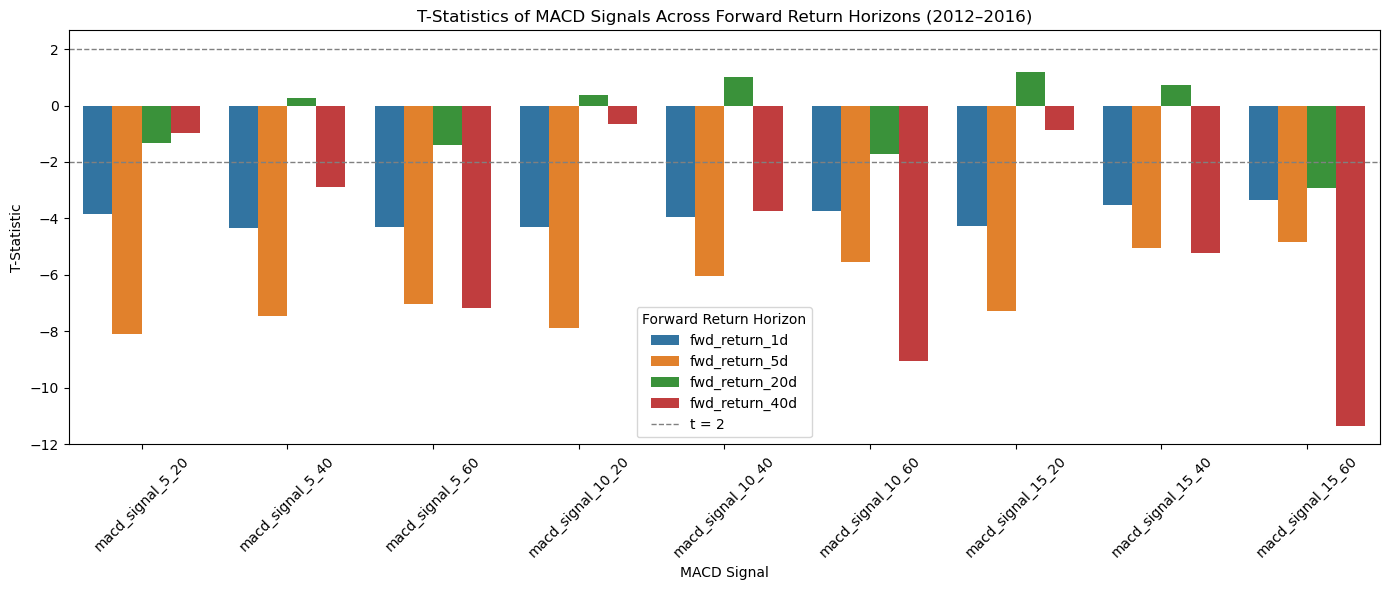

In [40]:
# Step 1: Prepare sorted DataFrame by ticker and date
df_macd = df.sort_values(['ticker', 'date']).copy()

# Step 2: Define all valid fast-slow EMA span pairs for MACD
fast_ema_spans = [5, 10, 15]
slow_ema_spans = [20, 40, 60]
macd_configs = [(f, s) for f in fast_ema_spans for s in slow_ema_spans if f < s]

# Step 3: Construct MACD signals for each (fast, slow) pair
for fast, slow in macd_configs:
    signal_span = max(3, slow // 4)  # Signal line EMA span
    short_col = f'ema_fast_{fast}_{slow}'
    long_col = f'ema_slow_{fast}_{slow}'
    macd_col = f'macd_line_{fast}_{slow}'
    sig_col = f'macd_signal_line_{fast}_{slow}'
    final_col = f'macd_signal_{fast}_{slow}'

    df_macd[short_col] = df_macd.groupby('ticker')['PX_LAST'].transform(lambda x: x.ewm(span=fast, adjust=False).mean())
    df_macd[long_col] = df_macd.groupby('ticker')['PX_LAST'].transform(lambda x: x.ewm(span=slow, adjust=False).mean())
    df_macd[macd_col] = df_macd[short_col] - df_macd[long_col]
    df_macd[sig_col] = df_macd.groupby('ticker')[macd_col].transform(lambda x: x.ewm(span=signal_span, adjust=False).mean())
    df_macd[final_col] = df_macd[macd_col] - df_macd[sig_col]

# Step 4: Extract all MACD signals into separate DataFrame
macd_signal_cols = [f'macd_signal_{f}_{s}' for f, s in macd_configs]
df_macd_signals = df_macd[['date', 'ticker'] + macd_signal_cols].copy()

# Step 5: Define in-sample training period for regression
train_df = df_macd[(df_macd['date'] >= '2012-01-01') & (df_macd['date'] <= '2016-12-31')].copy()
forward_returns = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d']

# Step 6: Run OLS regressions of each MACD signal vs forward returns
results = []
for col in macd_signal_cols:
    for target in forward_returns:
        sub = train_df[[col, target]].dropna()
        if len(sub) < 50:
            continue
        X = sm.add_constant(sub[col])
        y = sub[target]
        try:
            model = sm.OLS(y, X).fit()
            results.append({
                'signal': col,
                'target': target,
                't_stat': float(model.tvalues[col])
            })
        except:
            continue

result_df = pd.DataFrame(results)

# Step 7: Visualization of T-statistics
if not result_df.empty:
    plt.figure(figsize=(14, 6))
    sns.barplot(
        data=result_df,
        x='signal',
        y='t_stat',
        hue='target'
    )
    plt.axhline(2, color='gray', linestyle='--', linewidth=1, label='t = 2')
    plt.axhline(-2, color='gray', linestyle='--', linewidth=1)
    plt.xticks(rotation=45)
    plt.title("T-Statistics of MACD Signals Across Forward Return Horizons (2012–2016)")
    plt.ylabel("T-Statistic")
    plt.xlabel("MACD Signal")
    plt.legend(title="Forward Return Horizon")
    plt.tight_layout()
    plt.show()

In [41]:
# Select best MACD window (fast/slow) using RSI-style ranking

if not result_df.empty:
    tmp = result_df.copy()
    tmp['abs_t'] = tmp['t_stat'].abs()

    # Extract fast and slow spans from 'macd_signal_{fast}_{slow}'
    pairs = tmp['signal'].str.extract(r'macd_signal_(\d+)_(\d+)', expand=True).astype(int)
    tmp['fast'] = pairs[0]
    tmp['slow'] = pairs[1]

    # Aggregate t-stats for each MACD parameter pair
    rank_df = (
        tmp.groupby(['fast', 'slow'])['abs_t']
           .agg(min_abs_t='min', mean_abs_t='mean')
           .reset_index()
    )

    # Apply dense ranking (ascending); higher combined rank is better
    rank_df['min_rank'] = rank_df['min_abs_t'].rank(method='dense', ascending=True)
    rank_df['mean_rank'] = rank_df['mean_abs_t'].rank(method='dense', ascending=True)
    rank_df['rank_score'] = rank_df['min_rank'] + rank_df['mean_rank']

    # Select best (fast, slow) pair by highest rank_score, break ties with mean_abs_t
    best_row = (
        rank_df
        .sort_values(['rank_score', 'mean_abs_t'], ascending=[False, False])
        .iloc[0]
    )

    best_fast = int(best_row['fast'])
    best_slow = int(best_row['slow'])
    best_signal_col = f"macd_signal_{best_fast}_{best_slow}"

    print("Best MACD window (fast/slow) by min/mean |t| ranking (global across targets):")
    print(f"  fast={best_fast}, slow={best_slow}")
    print(f"  Min |t|: {best_row['min_abs_t']:.2f}")
    print(f"  Mean |t|: {best_row['mean_abs_t']:.2f}")
    print(f"  Rank Score: {int(best_row['rank_score'])}")
    print(f"  Selected MACD signal column: {best_signal_col}")

Best MACD window (fast/slow) by min/mean |t| ranking (global across targets):
  fast=15, slow=60
  Min |t|: 2.93
  Mean |t|: 5.61
  Rank Score: 18
  Selected MACD signal column: macd_signal_15_60


In [42]:
# Step: Merge the negative MACD signal (15, 60) into the main df
selected_macd_col = 'macd_signal_15_60'

# Extract and negate
df_macd_selected = df_macd[['date', 'ticker', selected_macd_col]].copy()
df_macd_selected[selected_macd_col] = -df_macd_selected[selected_macd_col]

# Merge into original df
df = df.merge(df_macd_selected, on=['date', 'ticker'], how='left')

In [43]:
df.tail()

,date,ticker,PX_HIGH,PX_LOW,PX_OPEN,PX_LAST,PX_VOLUME,PE_RATIO,PX_TO_BOOK_RATIO,PX_TO_SALES_RATIO,...,crossover_signal,classic_breakout_60_20,cont_breakout_mu60_lam5_d0.9,RSI_signal_60,momentum_60d,momentum_20d,momentum_200d,momentum_220d,momentum_80d,macd_signal_15_60
127369,2020-12-24,WFC,30.350,29.665,30.35,29.84,2961029.0,46.6354,0.7704,1.4291,...,-0.122974,-1.0,-3.523231,-0.209811,0.232908,0.038563,0.124516,-0.221841,0.212474,-0.228762
127370,2020-12-28,WFC,30.475,29.910,30.05,29.93,4327450.0,46.7761,0.7727,1.4334,...,-0.122435,-1.0,-3.170908,-0.210857,0.233677,0.046950,0.080378,-0.227536,0.185174,-0.194482
127371,2020-12-29,WFC,30.165,29.750,30.10,29.78,4343416.0,46.5416,0.7688,1.4262,...,-0.119230,-1.0,-2.853817,-0.193451,0.205303,0.082430,0.127999,-0.236376,0.181898,-0.144600
127372,2020-12-30,WFC,30.040,29.655,29.80,29.75,4007378.0,46.4948,0.7680,1.4248,...,-0.115719,-1.0,-2.568436,-0.179661,0.180017,0.055325,0.089901,-0.206038,0.166019,-0.093910
127373,2020-12-31,WFC,30.231,29.680,29.75,30.18,5096866.0,58.7160,0.7683,1.5197,...,-0.117304,-1.0,-2.311592,-0.202293,0.212585,0.045834,0.126112,-0.189907,0.227985,-0.080846


In [44]:
print(df['ticker'].unique())

['ACN' 'AMGN' 'AMT' 'BAX' 'BSX' 'CAT' 'CI' 'CLX' 'CMCSA' 'CME' 'COF'
 'COST' 'D' 'DHR' 'DUK' 'EBAY' 'EOG' 'FDX' 'FSLR' 'GE' 'GILD' 'HUM' 'ICE'
 'KKR' 'KO' 'MMM' 'MRK' 'MS' 'NDAQ' 'NEE' 'NEM' 'NKE' 'NOC' 'NSC' 'PRU'
 'QCOM' 'RL' 'SLB' 'TAP' 'TJX' 'TRV' 'TSN' 'UPS' 'USB' 'V' 'WFC']


In [45]:
print(df.columns.tolist())

['date', 'ticker', 'PX_HIGH', 'PX_LOW', 'PX_OPEN', 'PX_LAST', 'PX_VOLUME', 'PE_RATIO', 'PX_TO_BOOK_RATIO', 'PX_TO_SALES_RATIO', 'DAY_TO_DAY_TOT_RETURN_GROSS_DVDS', 'CUR_MKT_CAP', 'IVOL_DELTA', 'IVOL_IMPLIED_FORWARD', 'fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d', 'daily_rf_return', 'vrp_std_250', 'PE_RATIO_signal_60', 'PX_TO_BOOK_RATIO_signal_60', 'PX_TO_SALES_RATIO_signal_60', 'PX_LAST_EWMA_signal_span60', 'crossover_signal', 'classic_breakout_60_20', 'cont_breakout_mu60_lam5_d0.9', 'RSI_signal_60', 'momentum_60d', 'momentum_20d', 'momentum_200d', 'momentum_220d', 'momentum_80d', 'macd_signal_15_60']


In [46]:
# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Filter to include only data from 2012-01-01 to 2020-12-31
df = df[(df['date'] >= "2012-01-01") & (df['date'] <= "2020-12-31")].copy()

# Check for any NaN values
nan_exists = df.isna().any().any()
print("Contains NaN values:", nan_exists)

# Save to CSV
df.to_csv("final_stock_data_with_signal.csv", index=False)

Contains NaN values: False
